# CMPE 256 - Research Paper Citation Recommender
### Building the Dataset & Evaluating a Baseline Model

**Team:** The ArXivists

| Name | SJSU ID |
|---|---|
| Talina Shrotriya | |
| Sheetal Sattiraju | |
| Manjula Ganesh |018227469 |

**Goal:** Given a research paper, recommend the papers most likely to be cited alongside it -
useful for researchers discovering related work and for understanding the structure of the ML literature.

**Why this approach:** Citation links encode semantic similarity in a way that plain text search misses.
Two papers on the same topic may share no vocabulary but appear together in thousands of reference lists.
We can exploit this co-citation signal with collaborative filtering and compare it against a pure
content-based TF-IDF baseline to measure the gain from structural information.

| Section | What we do |
|---|---|
| **1 - Data Gathering** | Fetch 300-400k paper metadata records from arXiv OAI-PMH |
| **2 - Citation Links** | Fetch citation edges for each paper from Semantic Scholar |
| **3 - Data Merging** | Join both sources, remove cold-start papers, build integer index |
| **4 - EDA** | Understand paper distribution, citation graph structure, and coverage |
| **5 - Evaluation Framework** | Shared train/test split and reusable `evaluate_model` / `compare_models` |
| **6 - Baseline Model** | TF-IDF cosine similarity; evaluate Precision / Recall / NDCG@K |

**Output files** (saved to Google Drive):

| File | Contents |
|---|---|
| `papers.csv` | paper_idx, arxiv_id, title, abstract, text, categories, year, s2_fields, cite_pop |
| `citations.csv` | source_idx, target_idx (integer indices, in-sample only) |
| `citation_pop.csv` | citation popularity scores for the popularity baseline |

## Data setup

In [6]:
!pip install -q sickle tqdm

In [7]:
!pip install -q implicit

In [8]:
# all libraries needed

import json
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import requests

#general libraries needed
import math, random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#modelling libraries
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import networkx as nx
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print(f"numpy {np.__version__} | pandas {pd.__version__}")
print("Ready.")

numpy 2.0.2 | pandas 2.2.2
Ready.


---
## Google Drive Setup

I've mounted Google Drive here so the final dataset gets saved permanently.
All three output CSVs and the checkpoints go to the folder below -
we can pick up any interrupted run without re-fetching from scratch.

In [9]:
from google.colab import drive
drive.mount("/content/drive")

OUTPUT_DIR = Path("/content/drive/MyDrive/cmpe_256_project_files")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"output directory: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
output directory: /content/drive/MyDrive/cmpe_256_project_files


### Check for existing dataset

I've added a Drive check before doing anything expensive. If `papers.csv` and `citations.csv`
already exist there, we can load them directly and skip Sections 1-3 entirely.
Section 4 EDA and Section 5 baseline always run on whatever dataset is loaded here.

In [10]:
_papers_path = OUTPUT_DIR / "papers.csv"
_cits_path   = OUTPUT_DIR / "citations.csv"

if _papers_path.exists() and _cits_path.exists():
    # dtype=str for arxiv_id columns: IDs like "2301.12345" look like floats
    # and pandas would silently parse them as float64, breaking all set lookups.
    df_papers_f = pd.read_csv(_papers_path, dtype={"arxiv_id": str})
    df_cit_f    = pd.read_csv(_cits_path,   dtype={"source_id": str, "target_id": str})
    SKIP_PIPELINE = True
    print("found existing dataset in Google Drive:")
    print(f"  papers.csv    : {len(df_papers_f):,} rows")
    print(f"  citations.csv : {len(df_cit_f):,} rows")
    print("\nskipping Sections 1-3 -- jump to Section 4 for EDA")
else:
    SKIP_PIPELINE = False
    print("no existing dataset found in Drive -- will run the full pipeline")

found existing dataset in Google Drive:
  papers.csv    : 163,275 rows
  citations.csv : 1,910,207 rows

skipping Sections 1-3 -- jump to Section 4 for EDA


In [11]:
# I've put all tunable settings here so we can adjust them in one place.

# arXiv subcategories I've focused on (ML and related CS fields)
TARGET_CATS: set[str] = {"cs.LG", "cs.AI", "cs.CV", "cs.IR", "cs.CL", "stat.ML"}

# submission year range - I've extracted the year from the arXiv ID, not update_date
MIN_YEAR: int = 2018
MAX_YEAR: int = 2024

# expected unique papers after dedup: ~300-400k (cs + stat dominate, eess adds a few)
# 1M is the ceiling so we never sample down - we collect everything that matches
MAX_PAPERS: int = 1_000_000

# I've dropped papers below this degree so we can avoid cold-start noise in the CF models
MIN_DEGREE: int = 2

# --- Semantic Scholar ---
# I've read the API key from Colab Secrets (Secrets panel → key: SEMANTIC_API_KEY).
# Rate limits by tier:
#   no key / free key (Tier 1) : 1 req/s   - S2_WORKERS=1
#   Tier 2 (request at s2.org) : 10 req/s  - set S2_RPS=9.0, S2_WORKERS=5
# A free key still helps: requests are authenticated so arXiv papers are better matched.
try:
    from google.colab import userdata as _ud
    S2_API_KEY: str = _ud.get("SEMANTIC_API_KEY") or ""
except Exception:
    S2_API_KEY: str = ""

S2_ENDPOINT: str    = "https://api.semanticscholar.org/graph/v1/paper/batch"
S2_FIELDS: str      = "references.externalIds,fieldsOfStudy"
S2_BATCH_SIZE: int  = 500
S2_RPS: float       = 0.9   # 1 req/s for free key; raise to 9.0 for Tier 2
S2_WORKERS: int     = 1     # raise to 5 only when S2_RPS > 1 (Tier 2 key)
S2_CKPT_EVERY: int  = 100   # checkpoint every N batches so we can resume mid-fetch

# --- arXiv OAI-PMH ---
# I've chosen OAI-PMH because it's the official bulk-access method and requires no credentials.
# math is excluded: ~250k records to scan for only ~5k matches (~2%) is not worth it.
OAI_ENDPOINT: str   = "http://export.arxiv.org/oai2"
OAI_SETS: list[str] = ["cs", "stat", "eess"]

# I've split work into (set × year) tasks so we can parallelise within each set.
# 3 sets × 7 years = 21 tasks, each ~60-85k records, all running concurrently.
# Reduce to 10-12 if arXiv starts returning 503s.
OAI_WORKERS: int = 21

# I've used a conditional so the Drive mount cell's OUTPUT_DIR is not overridden
# when cells run top-to-bottom in Colab (Drive mount runs before this cell).
if "OUTPUT_DIR" not in vars():
    OUTPUT_DIR = Path(".")  # local fallback; Drive mount cell sets the real path on Colab

import numpy as np
np.random.seed(256)

print("config loaded")
print(f"output dir : {OUTPUT_DIR}")
print(f"S2 API key : {'set ✓' if S2_API_KEY else 'not set (using public rate limit)'}")

config loaded
output dir : /content/drive/MyDrive/cmpe_256_project_files
S2 API key : not set (using public rate limit)


---
## Section 1 - Data Gathering: arXiv Paper Metadata

I've used the official arXiv OAI-PMH bulk-access API so we can harvest metadata at scale
without any API key setup - it's arXiv's recommended method for batch downloads.

OAI-PMH is cursor-based (resumption tokens), so a single connection to the `cs` set
fetches 600k records sequentially. I've split the work into one task per **(set × year)**
- 3 sets × 7 years = **21 parallel tasks**, each fetching ~60-85k records, so we can
complete the full fetch in minutes instead of hours.

I've also switched from `metadataPrefix="oai_dc"` to `metadataPrefix="arXiv"` which
provides a dedicated `<categories>` element with space-separated arXiv codes
(e.g. `"cs.LG stat.ML"`). The `oai_dc` format only has human-readable strings like
`"Computer Science - Machine Learning"` in `dc:subject` - those never matched our filter.

| Set | Records scanned | Expected matches | Match rate |
|---|---|---|---|
| `cs` | ~600k | ~250-300k | ~45% |
| `stat` | ~80k | ~40-50k | ~55% |
| `eess` | ~60k | ~10-15k | ~15% |

After deduplication across sets: roughly **300-400k unique papers** total.
`MAX_PAPERS=1M` means no sampling - we keep everything that matches.

Expected runtime: **3-5 minutes** (21 concurrent streams, vs 20-35 min with 3).
Reduce `OAI_WORKERS` to 10-12 if arXiv returns persistent 503 errors.

In [12]:
def extract_year(arxiv_id: str, fallback_date: str = "") -> int | None:
    """
    Get the submission year from an arXiv ID.

    I've relied on the YYMM prefix in new-format IDs (post-2007) because it always
    reflects the v1 submission date. I've fallen back to the update_date string only
    for old-style IDs that predate this format.
    """
    match = re.match(r"^(\d{2})\d{2}\.\d+", arxiv_id)
    if match:
        yy = int(match.group(1))
        return 2000 + yy if yy < 90 else 1900 + yy
    if len(fallback_date) >= 4:
        try:
            return int(fallback_date[:4])
        except ValueError:
            pass
    return None


def clean_text(text: str | None) -> str:
    """Collapse whitespace and strip leading/trailing spaces."""
    if not text:
        return ""
    return re.sub(r"\s+", " ", text).strip()

---
### Debug: inspect a raw arXiv-prefix OAI-PMH record

I ran this cell once to confirm that `metadataPrefix="arXiv"` returns a dedicated
`<categories>` element with space-separated arXiv codes like `"cs.LG stat.ML"`.

The original code used `metadataPrefix="oai_dc"` where `dc:subject` contains
human-readable strings like `"Computer Science - Machine Learning"` instead of
category codes, which is why the regex matched only 1-2 records per set.

In [13]:
from sickle import Sickle as _Sickle
from xml.etree.ElementTree import fromstring as _xml_parse

_ARXIV_NS_DBG = "http://arxiv.org/OAI/arXiv/"
_sickle = _Sickle(OAI_ENDPOINT)
_records = _sickle.ListRecords(
    metadataPrefix="arXiv",
    set="cs",
    **{"from": "2023-01-01", "until": "2023-01-03"},
)

# I fetched just 3 records to confirm the arXiv prefix returns clean category codes
for _i, _rec in enumerate(_records):
    print(f"--- record {_i} ---")
    print(f"header.identifier : {_rec.header.identifier}")
    _root = _xml_parse(_rec.raw)
    _el = _root.find(f".//{{{_ARXIV_NS_DBG}}}arXiv")
    if _el is not None:
        print(f"categories        : {_el.findtext(f'{{{_ARXIV_NS_DBG}}}categories')}")
        print(f"title             : {(_el.findtext(f'{{{_ARXIV_NS_DBG}}}title') or '')[:80]}")
    print()
    if _i >= 2:
        break

--- record 0 ---
header.identifier : oai:arXiv.org:1711.06529
categories        : math.NA cond-mat.mtrl-sci
title             : Variational projector augmented-wave method: theoretical analysis and preliminar

--- record 1 ---
header.identifier : oai:arXiv.org:1712.04685
categories        : math.NA cond-mat.mtrl-sci
title             : Projector augmented-wave method: an analysis in a one-dimensional setting

--- record 2 ---
header.identifier : oai:arXiv.org:1810.01329
categories        : math.NA cond-mat.mtrl-sci
title             : Discretization error cancellation in the plane-wave approximation of periodic Ha



In [14]:
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from xml.etree.ElementTree import fromstring as _xml_parse
from tqdm.auto import tqdm

# arXiv OAI-PMH namespace for the arXiv metadata prefix
_ARXIV_NS = "http://arxiv.org/OAI/arXiv/"

# rough total record counts per set for 2018-2024 - divided by years for per-task ETA
_SET_TOTAL_EST = {
    "cs":   600_000,
    "stat":  80_000,
    "eess":  60_000,
}


def _parse_record(record) -> dict | None:
    """
    Extract one paper's fields from a sickle arXiv-prefix record.

    I switched from oai_dc to metadataPrefix="arXiv" because oai_dc puts
    human-readable strings in dc:subject (e.g. "Computer Science - Machine
    Learning") that don't match arXiv category codes. The arXiv prefix has a
    dedicated <categories> element with space-separated codes like "cs.LG stat.ML",
    so we get exact matches against TARGET_CATS without any fragile regex.

    Returns None if the record did not match target categories or year range.
    """
    try:
        oai_id = record.header.identifier
        arxiv_id = re.sub(r"v\d+$", "", oai_id.split("oai:arXiv.org:")[-1]).strip()
        if not arxiv_id:
            return None

        year = extract_year(arxiv_id)
        if year is None or not (MIN_YEAR <= year <= MAX_YEAR):
            return None

        root = _xml_parse(record.raw)
        arxiv_el = root.find(f".//{{{_ARXIV_NS}}}arXiv")
        if arxiv_el is None:
            return None

        cats_str = (arxiv_el.findtext(f"{{{_ARXIV_NS}}}categories") or "").strip()
        cats = cats_str.split()
        if not set(cats) & TARGET_CATS:
            return None

        title = clean_text(arxiv_el.findtext(f"{{{_ARXIV_NS}}}title") or "")
        abstract = clean_text(arxiv_el.findtext(f"{{{_ARXIV_NS}}}abstract") or "")

        authors_list = []
        for author_el in arxiv_el.findall(
            f"{{{_ARXIV_NS}}}authors/{{{_ARXIV_NS}}}author"
        ):
            keyname = author_el.findtext(f"{{{_ARXIV_NS}}}keyname") or ""
            forenames = author_el.findtext(f"{{{_ARXIV_NS}}}forenames") or ""
            if keyname:
                authors_list.append(f"{forenames} {keyname}".strip())

        return {
            "arxiv_id":   arxiv_id,
            "title":      title,
            "abstract":   abstract,
            "categories": " ".join(cats),
            "authors":    "; ".join(authors_list),
            "year":       year,
        }
    except Exception:
        return None


def _fetch_year(oai_set: str, year: int) -> tuple[str, int, list[dict]]:
    """
    Fetch all matching papers from one OAI-PMH set for a single calendar year.

    I check OUTPUT_DIR for a per-task checkpoint first. If the file exists we
    load and return immediately, so a resumed run skips all already-finished
    (set, year) pairs without hitting the OAI-PMH server at all.

    After a successful live fetch I write the results to a .tmp file and rename
    it into place atomically, so a session crash mid-write never leaves a corrupt
    checkpoint that would be silently loaded on the next run.

    Returns (oai_set, year, rows) so the caller can log per-task completions.
    """
    ckpt_path = OUTPUT_DIR / f"_ckpt_oai_{oai_set}_{year}.csv"

    if ckpt_path.exists():
        # dtype=str: arXiv IDs like "2301.12345" look like floats to pandas and
        # would be read as float64 without this, breaking all set/isin lookups.
        rows = pd.read_csv(ckpt_path, dtype=str).to_dict("records")
        tqdm.write(f"  [{oai_set}/{year}] checkpoint: {len(rows):,} papers (skipping fetch)")
        return oai_set, year, rows

    from sickle import Sickle

    sickle = Sickle(OAI_ENDPOINT, max_retries=3, retry_status_codes=[503, 429])
    rows: list[dict] = []
    n_years = MAX_YEAR - MIN_YEAR + 1
    est = _SET_TOTAL_EST.get(oai_set, 100_000) // n_years

    try:
        records = sickle.ListRecords(
            metadataPrefix="arXiv",
            set=oai_set,
            **{"from": f"{year}-01-01", "until": f"{year}-12-31"},
        )
        with tqdm(
            records,
            desc=f"  {oai_set}/{year}",
            total=est,
            leave=False,
            unit=" rec",
            dynamic_ncols=True,
        ) as pbar:
            for record in pbar:
                row = _parse_record(record)
                if row:
                    rows.append(row)
                pbar.set_postfix(kept=f"{len(rows):,}")

    except Exception as exc:
        tqdm.write(f"  [{oai_set}/{year}] stopped: {type(exc).__name__}: {exc}")

    # atomic write: .tmp then rename so a crash mid-write never corrupts the checkpoint
    if rows:
        tmp = ckpt_path.with_suffix(".tmp")
        pd.DataFrame(rows).to_csv(tmp, index=False)
        tmp.rename(ckpt_path)

    tqdm.write(f"  [{oai_set}/{year}] done: {len(rows):,} matched → saved to {ckpt_path.name}")
    return oai_set, year, rows


def load_oai_arxiv(
    min_year: int = MIN_YEAR,
    max_year: int = MAX_YEAR,
    max_papers: int | None = MAX_PAPERS,
    oai_sets: list[str] | None = None,
    workers: int = OAI_WORKERS,
) -> pd.DataFrame:
    """
    Fetch arXiv paper metadata from OAI-PMH with concurrent per-(set, year) streams.

    I split the work into one task per (set × year) pair so we can use up to 21
    parallel workers instead of just 3. Tasks that already have a checkpoint file
    in OUTPUT_DIR are loaded instantly and skipped, so a resumed run only fetches
    whatever was not yet completed when the session ended.

    Args:
        min_year: Earliest submission year to include (inclusive).
        max_year: Latest submission year to include (inclusive).
        max_papers: Cap on total unique papers. None means keep all.
        oai_sets: OAI-PMH top-level set names. Defaults to OAI_SETS.
        workers: Number of parallel threads.

    Returns:
        DataFrame with columns: arxiv_id, title, abstract, categories, authors, year.
    """
    if oai_sets is None:
        oai_sets = OAI_SETS

    tasks = [(s, y) for s in oai_sets for y in range(min_year, max_year + 1)]
    n_years = max_year - min_year + 1

    n_cached = sum(
        1 for s, y in tasks
        if (OUTPUT_DIR / f"_ckpt_oai_{s}_{y}.csv").exists()
    )
    print(
        f"launching {len(tasks)} tasks "
        f"({len(oai_sets)} sets × {n_years} years) with {workers} workers"
    )
    print(f"  checkpoints : {OUTPUT_DIR}")
    print(f"  cached      : {n_cached}/{len(tasks)} tasks will load from file\n")

    all_rows: list[dict] = []

    with ThreadPoolExecutor(max_workers=workers) as pool:
        futures = {pool.submit(_fetch_year, s, y): (s, y) for s, y in tasks}
        with tqdm(total=len(tasks), desc="tasks completed", unit=" task") as outer:
            for future in as_completed(futures):
                _, _, rows = future.result()
                all_rows.extend(rows)
                outer.update(1)
                outer.set_postfix(total_kept=f"{len(all_rows):,}")

    df = (
        pd.DataFrame(all_rows)
        .drop_duplicates(subset="arxiv_id")
        .reset_index(drop=True)
    )
    if max_papers and len(df) > max_papers:
        df = df.sample(n=max_papers, random_state=256).reset_index(drop=True)

    print(f"\nloaded {len(df):,} unique papers total")
    return df

In [15]:
if not SKIP_PIPELINE:
    # I kicked off the concurrent fetch here.
    # Each set prints its own progress so we can see all four streams running at once.
    df_papers = load_oai_arxiv()

In [16]:
if not SKIP_PIPELINE:
    # I ran a quick sanity check before moving on to catch any obvious issues early.
    print(f"shape         : {df_papers.shape}")
    print(f"null titles   : {df_papers['title'].isna().sum()}")
    print(f"null abstracts: {df_papers['abstract'].isna().sum()}")
    print(f"year range    : {df_papers['year'].min()} - {df_papers['year'].max()}")
    display(df_papers.head(3))

---
## Section 2: Fetching Citation Links from Semantic Scholar

arXiv does not have citation data, so I used the Semantic Scholar batch API.
For each paper in my dataset, S2 returned the list of papers it referenced
along with their arXiv IDs when available. I sent 500 paper IDs per request
to maximize throughput within each API call.

**Rate limiting:** S2 enforces ~1 req/s on the public endpoint. I used a shared
`_S2RateLimiter` token bucket across all worker threads so the combined rate
never exceeds the limit regardless of worker count.

**Speeding this up:** Get a free API key at `semanticscholar.org/product/api` -
it unlocks ~10 req/s. Then set `S2_API_KEY`, `S2_RPS=9.0`, `S2_WORKERS=5`
in the config cell for roughly 10× faster fetching (~4 min instead of ~40 min
for 300k papers).

The progress bar shows live links found, S2 coverage %, actual req/s, and a
rolling ETA. Any 429 responses are retried once after honoring the `Retry-After`
header, and failed batches are counted and reported at the end.

In [17]:
import threading


class _S2RateLimiter:
    """
    Thread-safe token bucket that spaces S2 requests to at most `rps` per second.

    I used a shared lock so all workers compete for the same rate budget rather
    than each sleeping independently, which would let the combined rate exceed
    the S2 limit and trigger 429s.
    """
    def __init__(self, rps: float):
        self._interval = 1.0 / rps
        self._lock = threading.Lock()
        self._next_allowed = 0.0

    def acquire(self) -> None:
        with self._lock:
            now = time.monotonic()
            wait = self._next_allowed - now
            if wait > 0:
                time.sleep(wait)
            self._next_allowed = time.monotonic() + self._interval


def fetch_s2_batch(
    arxiv_ids: list[str],
    headers: dict | None = None,
    endpoint: str = S2_ENDPOINT,
    fields: str = S2_FIELDS,
) -> tuple[list[tuple[str, str]], dict[str, str]]:
    """
    Fetch one batch of citation data from Semantic Scholar.

    Args:
        arxiv_ids: List of arXiv IDs (no version suffix).
        headers: Optional request headers (e.g. {"x-api-key": key}).
        endpoint: S2 batch API URL.
        fields: Comma-separated fields to request.

    Returns:
        citation_pairs: List of (source_id, target_id) tuples.
        fields_map: Dict of arxiv_id -> fields-of-study string.

    Raises:
        requests.HTTPError: On non-200 response.
    """
    resp = requests.post(
        endpoint,
        params={"fields": fields},
        json={"ids": [f"arXiv:{pid}" for pid in arxiv_ids]},
        headers=headers or {},
        timeout=60,
    )
    resp.raise_for_status()

    pairs: list[tuple[str, str]] = []
    fields_map: dict[str, str] = {}

    for src_id, paper in zip(arxiv_ids, resp.json()):
        if paper is None:
            continue
        fos = paper.get("fieldsOfStudy") or []
        if fos:
            fields_map[src_id] = ", ".join(fos)
        for ref in paper.get("references") or []:
            cited = (ref.get("externalIds") or {}).get("ArXiv")
            if cited:
                pairs.append((src_id, re.sub(r"v\d+$", "", cited.strip())))

    return pairs, fields_map


def _fetch_batch_safe(
    batch_idx: int,
    arxiv_ids: list[str],
    limiter: _S2RateLimiter,
    headers: dict,
) -> tuple[int, list[str], list[tuple[str, str]], dict[str, str], bool]:
    """
    Fetch one S2 batch with rate-limit enforcement and a single 429 retry.

    I respected the Retry-After header on 429s instead of using a fixed backoff
    so we wait exactly as long as S2 asks and don't over-sleep.

    Returns (batch_idx, arxiv_ids, pairs, fields_map, ok). Passing arxiv_ids back
    lets the caller mark those IDs as done in the checkpoint without maintaining
    a separate batch-index-to-IDs mapping.
    ok=False means the whole batch failed - its IDs are NOT added to the done set
    so they will be retried on the next run.
    """
    for attempt in range(2):
        limiter.acquire()
        try:
            pairs, fmap = fetch_s2_batch(arxiv_ids, headers=headers)
            return batch_idx, arxiv_ids, pairs, fmap, True

        except requests.HTTPError as exc:
            status = exc.response.status_code
            if status == 429:
                retry_after = int(exc.response.headers.get("Retry-After", 30))
                tqdm.write(
                    f"  [429] batch {batch_idx}: "
                    f"rate limited - sleeping {retry_after}s then retrying"
                )
                time.sleep(retry_after)
                continue
            tqdm.write(f"  [HTTP {status}] batch {batch_idx}: skipped")
            return batch_idx, arxiv_ids, [], {}, False

        except Exception as exc:
            tqdm.write(f"  [error] batch {batch_idx}: {type(exc).__name__}: {exc}")
            return batch_idx, arxiv_ids, [], {}, False

    tqdm.write(f"  [failed] batch {batch_idx}: gave up after 429 retry")
    return batch_idx, arxiv_ids, [], {}, False

In [18]:
def fetch_s2_citations(
    arxiv_ids: list[str],
    batch_size: int = S2_BATCH_SIZE,
    rps: float = S2_RPS,
    workers: int = S2_WORKERS,
    api_key: str = S2_API_KEY,
    ckpt_every: int = S2_CKPT_EVERY,
) -> tuple[pd.DataFrame, dict[str, str]]:
    """
    Fetch all citation links from Semantic Scholar with parallel workers, a shared
    rate limiter, and incremental checkpointing to Google Drive.

    I save three checkpoint files to OUTPUT_DIR every `ckpt_every` completed batches:
      _ckpt_s2_pairs.csv   -- all citation pairs collected so far
      _ckpt_s2_fields.json -- fields-of-study map collected so far
      _ckpt_s2_done.json   -- sorted list of arxiv_ids successfully sent to S2

    Checkpoint staleness check: before trusting the checkpoint I verify that at
    least 50% of the current arxiv_ids appear in the saved done set. A lower
    overlap means the checkpoint is from a different OAI-PMH run (different paper
    set) and would produce source IDs that don't match df_papers, causing 0
    in-sample citations. In that case I discard the checkpoint and start fresh.

    All checkpoint writes use .tmp → rename to prevent partial files on crash.
    Failed batches (ok=False) are NOT marked done so they are retried on next run.

    Args:
        arxiv_ids: All arXiv IDs to look up.
        batch_size: IDs per request (S2 max is 500).
        rps: Max requests per second shared across all workers.
        workers: Concurrent fetch threads.
        api_key: Optional S2 API key.
        ckpt_every: Save checkpoint every N completed batches.

    Returns:
        df_citations: DataFrame with columns source_id, target_id.
        s2_fields_map: Dict of arxiv_id -> fields-of-study string.
    """
    from concurrent.futures import ThreadPoolExecutor, as_completed

    ckpt_pairs  = OUTPUT_DIR / "_ckpt_s2_pairs.csv"
    ckpt_fields = OUTPUT_DIR / "_ckpt_s2_fields.json"
    ckpt_done   = OUTPUT_DIR / "_ckpt_s2_done.json"

    # --- resume from checkpoint if available ---
    all_pairs: list[tuple[str, str]] = []
    s2_fields_map: dict[str, str] = {}
    done_ids: set[str] = set()

    if ckpt_done.exists():
        saved_done = set(json.loads(ckpt_done.read_text()))
        current_ids = set(arxiv_ids)
        overlap_frac = len(saved_done & current_ids) / max(len(current_ids), 1)

        if overlap_frac < 0.5:
            # checkpoint is from a different OAI-PMH run - source IDs won't match
            # current df_papers, which would cause 0 in-sample citations downstream
            print(
                f"  stale S2 checkpoint: only {overlap_frac:.0%} of current IDs found in saved set\n"
                f"  discarding checkpoint and starting fresh"
            )
        else:
            done_ids = saved_done & current_ids  # only keep IDs relevant to this run
            if ckpt_pairs.exists():
                # dtype=str: arXiv IDs like "2301.12345" parse as float64 without this,
                # making isin() comparisons with string paper_ids return all-False
                _df = pd.read_csv(ckpt_pairs, dtype={"source_id": str, "target_id": str})
                # filter to pairs whose source is in the current paper set
                _df = _df[_df["source_id"].isin(current_ids)]
                all_pairs = list(zip(_df["source_id"], _df["target_id"]))
            if ckpt_fields.exists():
                s2_fields_map = json.loads(ckpt_fields.read_text())

    # --- build batch list and skip already-done batches ---
    all_batches = [
        arxiv_ids[i : i + batch_size]
        for i in range(0, len(arxiv_ids), batch_size)
    ]
    pending = [
        (i, batch) for i, batch in enumerate(all_batches)
        if not done_ids.issuperset(batch)
    ]
    n_skipped = len(all_batches) - len(pending)

    print(f"S2 citation fetch")
    print(f"  papers    : {len(arxiv_ids):,}")
    print(f"  batches   : {len(all_batches):,} total | {n_skipped:,} already done | {len(pending):,} to fetch")
    print(f"  rate      : {rps} req/s  |  workers: {workers}")
    print(f"  ETA       : ~{len(pending) / rps / 60:.0f} min")
    print(f"  checkpoint: every {ckpt_every} batches → {OUTPUT_DIR}")
    if done_ids:
        print(f"  resumed   : {len(done_ids):,} IDs already processed | {len(all_pairs):,} pairs loaded")
    if not api_key:
        print(
            "  tip: a free S2 API key unlocks higher rate limits → "
            "set S2_API_KEY, S2_RPS, S2_WORKERS"
        )
    print()

    def _save_checkpoint() -> None:
        """Atomically write all three checkpoint files."""
        for path, write_fn in [
            (ckpt_pairs,  lambda p: pd.DataFrame(all_pairs, columns=["source_id", "target_id"]).to_csv(p, index=False)),
            (ckpt_fields, lambda p: p.write_text(json.dumps(s2_fields_map))),
            (ckpt_done,   lambda p: p.write_text(json.dumps(sorted(done_ids)))),
        ]:
            tmp = path.with_suffix(".tmp")
            write_fn(tmp)
            tmp.rename(path)

    if not pending:
        print("all batches already checkpointed - skipping S2 fetch")
        df_cit = pd.DataFrame(all_pairs, columns=["source_id", "target_id"])
        return df_cit, s2_fields_map

    headers = {"x-api-key": api_key} if api_key else {}
    limiter = _S2RateLimiter(rps)
    n_failed = 0
    n_since_ckpt = 0
    t_start = time.monotonic()

    with ThreadPoolExecutor(max_workers=workers) as pool:
        futures = {
            pool.submit(_fetch_batch_safe, i, batch, limiter, headers): i
            for i, batch in pending
        }
        with tqdm(
            total=len(pending),
            desc="S2 batches",
            unit=" batch",
            dynamic_ncols=True,
        ) as pbar:
            for future in as_completed(futures):
                idx, batch_ids, pairs, fmap, ok = future.result()
                all_pairs.extend(pairs)
                s2_fields_map.update(fmap)
                if ok:
                    done_ids.update(batch_ids)
                else:
                    n_failed += 1

                n_since_ckpt += 1
                if n_since_ckpt >= ckpt_every:
                    _save_checkpoint()
                    n_since_ckpt = 0
                    tqdm.write(
                        f"  checkpoint saved: {len(all_pairs):,} pairs | "
                        f"{len(done_ids):,} IDs done"
                    )

                elapsed = time.monotonic() - t_start
                done = pbar.n + 1
                req_rate = done / elapsed if elapsed > 0 else 0
                remaining = (len(pending) - done) / req_rate if req_rate > 0 else 0
                pbar.update(1)
                pbar.set_postfix(
                    links=f"{len(all_pairs):,}",
                    coverage=f"{100 * len(s2_fields_map) / len(arxiv_ids):.1f}%",
                    req_s=f"{req_rate:.2f}",
                    eta=f"{remaining / 60:.1f}m",
                    err=n_failed or "",
                )

    _save_checkpoint()

    df_cit = pd.DataFrame(all_pairs, columns=["source_id", "target_id"])
    elapsed_min = (time.monotonic() - t_start) / 60
    coverage_pct = 100 * len(s2_fields_map) / len(arxiv_ids)

    print(f"\nS2 fetch complete  ({elapsed_min:.1f} min)")
    print(f"  citation links   : {len(df_cit):,}")
    print(f"  unique sources   : {df_cit['source_id'].nunique():,}")
    print(f"  unique targets   : {df_cit['target_id'].nunique():,}")
    print(f"  S2 coverage      : {coverage_pct:.1f}%  ({len(s2_fields_map):,} / {len(arxiv_ids):,} papers)")
    avg_refs = len(df_cit) / max(df_cit["source_id"].nunique(), 1)
    print(f"  avg refs / paper : {avg_refs:.1f}")
    if n_failed:
        print(f"  failed batches   : {n_failed}  ({n_failed * batch_size:,} IDs affected - will retry on next run)")

    return df_cit, s2_fields_map

In [19]:
if not SKIP_PIPELINE:
    arxiv_ids = df_papers["arxiv_id"].tolist()
    df_citations_raw, s2_fields_map = fetch_s2_citations(arxiv_ids)

In [20]:
if not SKIP_PIPELINE:
    # I saved intermediate results to Google Drive so we can resume from this point
    # if Colab disconnects before Section 3 finishes.
    df_papers.to_csv(OUTPUT_DIR / "_checkpoint_papers.csv", index=False)
    df_citations_raw.to_csv(OUTPUT_DIR / "_checkpoint_citations_raw.csv", index=False)

    with open(OUTPUT_DIR / "_checkpoint_s2_fields.json", "w") as f:
        json.dump(s2_fields_map, f)

    print(f"checkpoints saved to {OUTPUT_DIR}")

---
### Resume from checkpoint (run only if Colab disconnected before Section 3)

If I had to restart my runtime after saving the checkpoints above, I loaded them
here instead of re-running Sections 1 and 2.
Skip this cell if `df_papers` and `df_citations_raw` are still in memory.

In [21]:
if not SKIP_PIPELINE:
    _ckpt_papers = OUTPUT_DIR / "_checkpoint_papers.csv"
    _ckpt_cit    = OUTPUT_DIR / "_checkpoint_citations_raw.csv"
    _ckpt_fields = OUTPUT_DIR / "_checkpoint_s2_fields.json"

    if _ckpt_papers.exists() and _ckpt_cit.exists():
        # dtype=str prevents "2301.12345" from being read back as float64
        df_papers        = pd.read_csv(_ckpt_papers, dtype={"arxiv_id": str})
        df_citations_raw = pd.read_csv(_ckpt_cit,    dtype={"source_id": str, "target_id": str})
        s2_fields_map    = json.loads(_ckpt_fields.read_text()) if _ckpt_fields.exists() else {}
        print(f"loaded from checkpoint: {len(df_papers):,} papers, {len(df_citations_raw):,} raw links")
    else:
        print("no checkpoint files found - run Sections 1 and 2 first")

---
## Section 3: Joining arXiv and S2 Data into the Final Combined Dataset

This is where I joined the two sources into a single dataset:

- **From arXiv OAI-PMH** (Section 1): `arxiv_id`, `title`, `abstract`, `categories`, `authors`, `year`
- **From Semantic Scholar** (Section 2): `s2_fields` (field of study), `cite_pop` (normalized in-sample citation count), and the full `citations.csv` edge list

The join key is `arxiv_id`. After joining I also needed to:

1. Keep only citations where both the source and target paper were in my dataset
2. Drop papers with very few connections to avoid cold-start noise
3. Build a clean 0-based integer index so the sparse matrix models can use it directly

The output of this section is `df_papers_f` and `df_cit_f`, which are the fully combined
dataset that Section 4 runs EDA on and that we save to Google Drive.

In [22]:
def filter_in_sample_citations(
    df_citations: pd.DataFrame,
    paper_ids: set[str],
) -> pd.DataFrame:
    """
    Keep only citations where both source and target are in paper_ids.

    I coerce source_id and target_id to str before the isin() check because
    arXiv IDs like "2301.12345" are valid floats and pandas parses them as
    float64 when reading CSVs. Without the cast, float 2301.12345 != str
    "2301.12345" and isin() returns all-False, giving 0 in-sample citations.

    I also removed self-citations and duplicate edges here so we get a clean
    directed graph with no noise before building the sparse matrix.

    Args:
        df_citations: Raw citation pairs (source_id, target_id).
        paper_ids: Set of valid arXiv IDs (strings).

    Returns:
        Filtered DataFrame.
    """
    paper_ids_str = {str(p) for p in paper_ids}
    src = df_citations["source_id"].astype(str)
    tgt = df_citations["target_id"].astype(str)
    mask = src.isin(paper_ids_str) & tgt.isin(paper_ids_str) & (src != tgt)
    return (
        df_citations[mask]
        .assign(source_id=src[mask].values, target_id=tgt[mask].values)
        .drop_duplicates()
        .reset_index(drop=True)
    )

In [23]:
def filter_cold_start(
    df_papers: pd.DataFrame,
    df_citations: pd.DataFrame,
    min_degree: int = 2,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Remove papers with fewer than min_degree total citation connections.

    I computed each paper's degree as in-degree plus out-degree. Papers below
    the threshold were cold-start cases that would hurt CF model quality because
    the matrix factorization models need at least some signal per paper to learn
    a meaningful embedding. Removing them gave us a cleaner training set.

    Args:
        df_papers: Paper metadata DataFrame.
        df_citations: In-sample citation pairs.
        min_degree: Minimum total degree to keep a paper.

    Returns:
        Filtered (df_papers, df_citations) tuple.
    """
    degree = pd.concat([
        df_citations["source_id"].value_counts(),
        df_citations["target_id"].value_counts(),
    ]).groupby(level=0).sum()

    connected = set(degree[degree >= min_degree].index)

    df_p = df_papers[df_papers["arxiv_id"].isin(connected)].reset_index(drop=True)
    remaining = set(df_p["arxiv_id"])
    df_c = df_citations[
        df_citations["source_id"].isin(remaining)
        & df_citations["target_id"].isin(remaining)
    ].reset_index(drop=True)

    n_removed = len(df_papers) - len(df_p)
    print(f"removed {n_removed:,} cold-start papers (degree < {min_degree})")
    return df_p, df_c

In [24]:
def build_integer_index(
    df_papers: pd.DataFrame,
    df_citations: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Add a 0-based integer paper_idx to papers and resolve it in citations.

    I chose 0-based integer indexing because scipy sparse matrices and the
    ALS/SVD libraries expect rows and columns to be contiguous integers. This
    gave us direct compatibility with those libraries without any extra mapping.

    Args:
        df_papers: Paper metadata (must have arxiv_id column).
        df_citations: Citation pairs (must have source_id, target_id columns).

    Returns:
        Updated (df_papers, df_citations) with integer index columns added.
    """
    df_p = df_papers.reset_index(drop=True).copy()
    df_p["paper_idx"] = df_p.index

    id_to_idx: dict[str, int] = dict(zip(df_p["arxiv_id"], df_p["paper_idx"]))

    df_c = df_citations.copy()
    df_c["source_idx"] = df_c["source_id"].map(id_to_idx)
    df_c["target_idx"] = df_c["target_id"].map(id_to_idx)
    df_c = df_c.dropna(subset=["source_idx", "target_idx"]).reset_index(drop=True)
    df_c[["source_idx", "target_idx"]] = df_c[["source_idx", "target_idx"]].astype(int)

    return df_p, df_c

In [25]:
def add_computed_fields(
    df_papers: pd.DataFrame,
    df_citations: pd.DataFrame,
    s2_fields_map: dict[str, str],
) -> pd.DataFrame:
    """
    Add derived columns that the models would need.

    Columns added:
        primary_cat: First listed arXiv category.
        s2_fields: Semantic Scholar fields of study (e.g. "Computer Science").
        text: Title repeated twice + abstract. I repeated the title to give it
              higher TF-IDF weight because titles carry the most informative
              signal per word and this gave us better content similarity results.
        cite_pop: Normalized in-sample citation count from 0 to 1, used by the
                  baseline model as a popularity score.

    Args:
        df_papers: Paper metadata with paper_idx already added.
        df_citations: Filtered in-sample citations.
        s2_fields_map: Dict from arxiv_id to fields-of-study string.

    Returns:
        Updated df_papers with new columns.
    """
    df = df_papers.copy()
    df["primary_cat"] = df["categories"].str.split().str[0]
    df["s2_fields"] = df["arxiv_id"].map(s2_fields_map).fillna("")
    df["text"] = df["title"] + " " + df["title"] + " " + df["abstract"]

    raw_counts = df_citations["target_id"].value_counts()
    max_count = raw_counts.max() if len(raw_counts) > 0 else 1
    df["cite_pop"] = (
        df["arxiv_id"].map((raw_counts / max_count).to_dict()).fillna(0.0)
    )
    return df

In [26]:
if not SKIP_PIPELINE:
    paper_ids = set(df_papers["arxiv_id"].astype(str))

    # diagnostic: show source and target overlap separately so mismatches are obvious
    src_overlap = df_citations_raw["source_id"].astype(str).isin(paper_ids).mean()
    tgt_overlap = df_citations_raw["target_id"].astype(str).isin(paper_ids).mean()
    print(f"overlap check (before filter):")
    print(f"  source_id in paper_ids : {src_overlap:.1%}  ← should be ~100% (S2 queried our papers)")
    print(f"  target_id in paper_ids : {tgt_overlap:.1%}  ← expected 5-20% (only same-domain papers)")
    if src_overlap < 0.9:
        print("  WARNING: source overlap is low - S2 checkpoint may be from a different OAI-PMH run")
        print("  delete _ckpt_s2_*.csv / .json from Drive and re-run Section 2")
    print()

    # Step 1: I filtered down to in-sample citations only
    df_cit_in = filter_in_sample_citations(df_citations_raw, paper_ids)

    total = len(df_citations_raw)
    kept  = len(df_cit_in)
    print(f"raw links : {total:,}")
    print(f"in-sample : {kept:,} ({100 * kept / total:.2f}%)")

In [27]:
if not SKIP_PIPELINE:
    # Step 2: I dropped cold-start papers to give us a denser, cleaner training set
    df_papers_f, df_cit_f = filter_cold_start(df_papers, df_cit_in, min_degree=MIN_DEGREE)
    print(f"papers: {len(df_papers_f):,} | citations: {len(df_cit_f):,}")

In [28]:
if not SKIP_PIPELINE:
    # Step 3: I built the integer index so we can plug directly into scipy and ALS
    df_papers_f, df_cit_f = build_integer_index(df_papers_f, df_cit_f)
    print(f"paper_idx range: 0 - {df_papers_f['paper_idx'].max()}")

In [29]:
if not SKIP_PIPELINE:
    # Step 4: I joined S2 fields and citation popularity into df_papers_f.
    # After this cell df_papers_f is the final combined arXiv + S2 dataset.
    df_papers_f = add_computed_fields(df_papers_f, df_cit_f, s2_fields_map)
    print("combined dataset columns:", df_papers_f.columns.tolist())

In [30]:
def save_datasets(
    df_papers: pd.DataFrame,
    df_citations: pd.DataFrame,
    output_dir: Path = OUTPUT_DIR,
) -> None:
    """Save the three final CSV files to output_dir (Google Drive)."""
    paper_cols = [
        "paper_idx", "arxiv_id", "title", "abstract", "text",
        "categories", "primary_cat", "year", "authors", "s2_fields", "cite_pop",
    ]
    df_papers[paper_cols].to_csv(output_dir / "papers.csv", index=False)
    print(f"papers.csv       : {len(df_papers):,} rows  ->  {output_dir / 'papers.csv'}")

    cit_cols = ["source_idx", "target_idx", "source_id", "target_id"]
    df_citations[cit_cols].to_csv(output_dir / "citations.csv", index=False)
    print(f"citations.csv    : {len(df_citations):,} rows  ->  {output_dir / 'citations.csv'}")

    pop = (
        df_citations["target_id"].value_counts()
        .reset_index()
        .rename(columns={"target_id": "arxiv_id", "count": "raw_cite_count"})
    )
    pop["cite_pop_norm"] = pop["raw_cite_count"] / pop["raw_cite_count"].max()
    pop.to_csv(output_dir / "citation_pop.csv", index=False)
    print(f"citation_pop.csv : {len(pop):,} rows  ->  {output_dir / 'citation_pop.csv'}")


if not SKIP_PIPELINE:
    # I saved to Google Drive so the dataset persists across Colab sessions
    save_datasets(df_papers_f, df_cit_f)

---
## Section 4: Exploratory Data Analysis

I ran all EDA on `df_papers_f` and `df_cit_f`, which are the fully combined arXiv + S2
dataset produced by Section 3. Every plot and stat below reflects the joined dataset
that was saved to Google Drive.

I looked at the paper distribution, citation graph structure, and coverage stats.
This helped me catch data quality issues early and gave us a sense of what the models
would be working with.

In [31]:
# I computed basic stats first to confirm the dataset looked reasonable
n_papers = len(df_papers_f)
n_citations = len(df_cit_f)

print(f"papers          : {n_papers:,}")
print(f"citation links  : {n_citations:,}")
print(f"avg refs/paper  : {n_citations / n_papers:.1f}")
print(f"null abstracts  : {(df_papers_f['abstract'].str.len() == 0).sum()}")
print(f"s2 field coverage: {(df_papers_f['s2_fields'].str.len() > 0).mean():.1%}")

papers          : 163,275
citation links  : 1,910,207
avg refs/paper  : 11.7
null abstracts  : 0
s2 field coverage: 100.0%


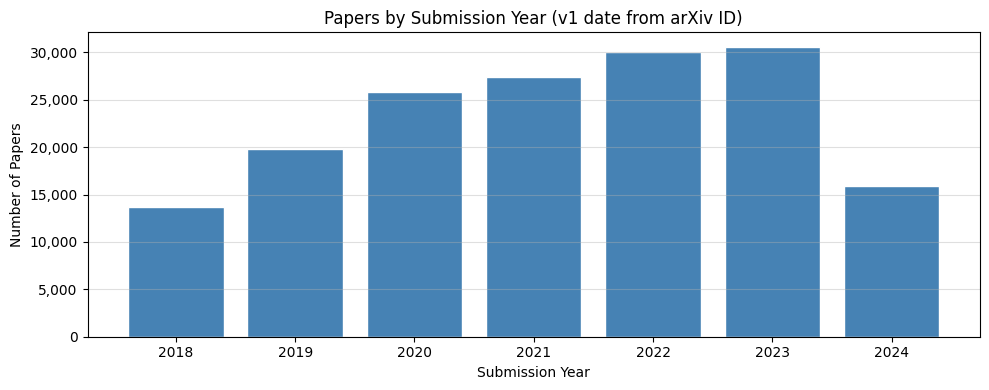

year
2018    13724
2019    19781
2020    25860
2021    27394
2022    30030
2023    30586
2024    15900


In [32]:
def plot_year_distribution(df: pd.DataFrame) -> None:
    """Bar chart of paper count per submission year."""
    counts = df["year"].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white")
    ax.set_xlabel("Submission Year")
    ax.set_ylabel("Number of Papers")
    ax.set_title("Papers by Submission Year (v1 date from arXiv ID)")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()
    plt.show()
    print(counts.to_string())


plot_year_distribution(df_papers_f)

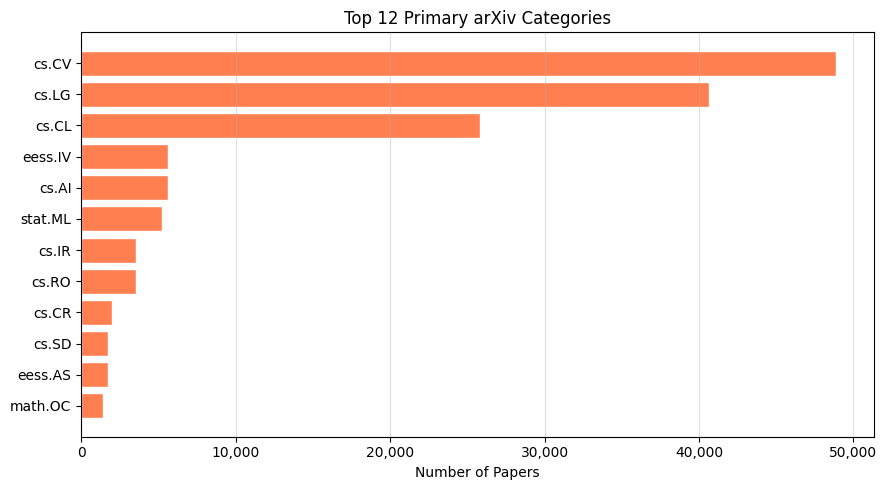

In [33]:
def plot_category_distribution(df: pd.DataFrame, top_n: int = 12) -> None:
    """Horizontal bar chart of the top-N primary arXiv categories."""
    counts = df["primary_cat"].value_counts().head(top_n)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(counts.index[::-1], counts.values[::-1], color="coral", edgecolor="white")
    ax.set_xlabel("Number of Papers")
    ax.set_title(f"Top {top_n} Primary arXiv Categories")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="x", alpha=0.4)
    plt.tight_layout()
    plt.show()


plot_category_distribution(df_papers_f)

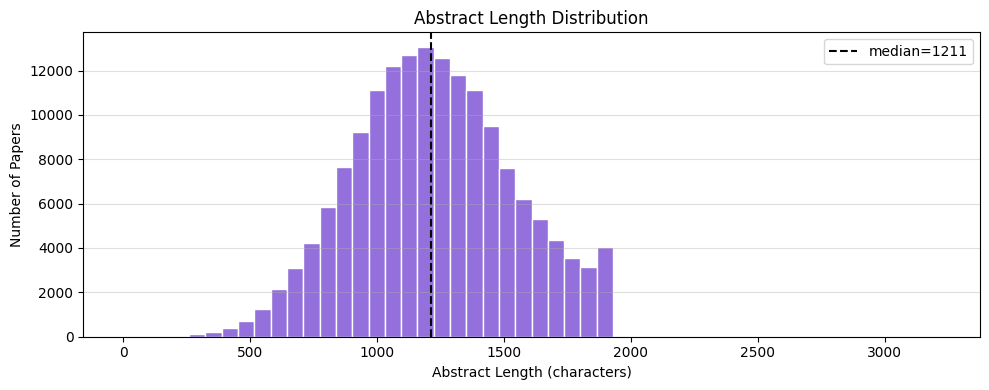

abstract length stats:
count    163275
mean       1221
std         316
min           3
25%        1001
50%        1211
75%        1433
max        3214
Name: abstract, dtype: int64


In [34]:
def plot_abstract_lengths(df: pd.DataFrame) -> None:
    """Histogram of abstract character lengths to check for truncation or stubs."""
    lengths = df["abstract"].str.len()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(lengths, bins=50, color="mediumpurple", edgecolor="white")
    ax.set_xlabel("Abstract Length (characters)")
    ax.set_ylabel("Number of Papers")
    ax.set_title("Abstract Length Distribution")
    ax.axvline(lengths.median(), color="black", linestyle="--", label=f"median={lengths.median():.0f}")
    ax.legend()
    ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()
    plt.show()

    print(f"abstract length stats:\n{lengths.describe().round(0).astype(int)}")


plot_abstract_lengths(df_papers_f)

In [35]:
# I checked which S2 fields of study appeared most often in the dataset.
# This told us whether the papers were actually from the right domain.
s2_field_counts = (
    df_papers_f["s2_fields"]
    .str.split(", ")
    .explode()
    .loc[lambda s: s.str.len() > 0]
    .value_counts()
)
print("top S2 fields of study:")
print(s2_field_counts.head(10).to_string())
print(f"\npapers with no S2 field: {(df_papers_f['s2_fields'].str.len() == 0).sum():,}")

top S2 fields of study:
s2_fields
Computer Science     162615
Mathematics           34409
Engineering           19813
Medicine              11017
Physics                6033
Biology                2421
Economics               938
Psychology              373
Materials Science       119
Sociology                75

papers with no S2 field: 0


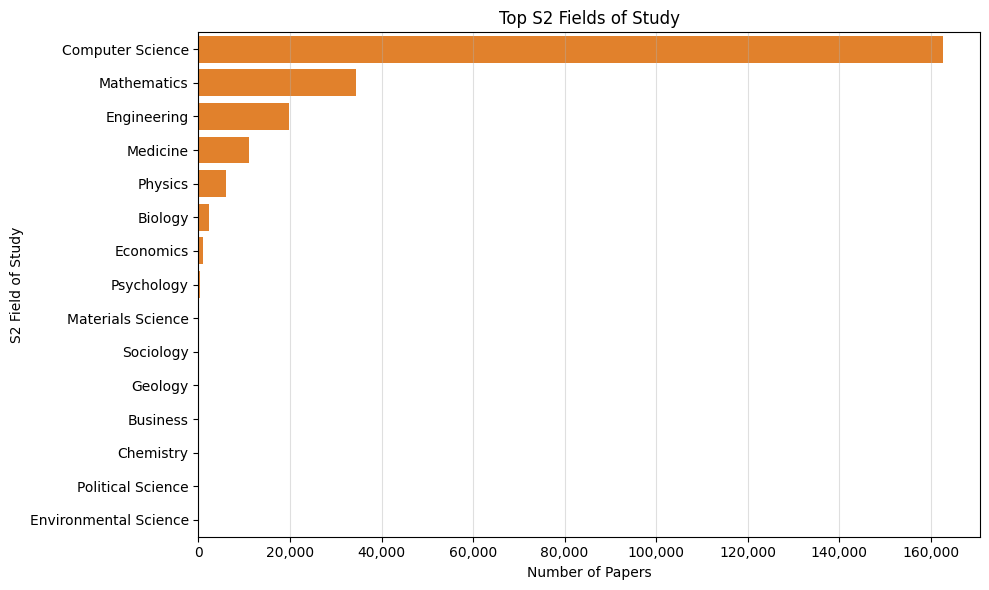

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top S2 fields (e.g., top 10 or 15)
top_s2_fields = s2_field_counts.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_s2_fields.values, y=top_s2_fields.index, palette=["#FF7F0E"] * len(top_s2_fields), ax=ax, hue=top_s2_fields.index, legend=False) # Using a specific orange color, explicitly setting hue and disabling legend

ax.set_xlabel("Number of Papers")
ax.set_ylabel("S2 Field of Study")
ax.set_title("Top S2 Fields of Study")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}')) # Format x-axis labels with commas
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

In [36]:
# I measured what fraction of raw S2 links stayed in-sample after filtering.
# A low number (under 1%) would mean the paper set was too small for good CF performance,
# so we would need to increase MAX_PAPERS.
total_in = len(df_cit_f)
papers_citing = df_cit_f["source_id"].nunique()
papers_cited  = df_cit_f["target_id"].nunique()

if not SKIP_PIPELINE:
    total_raw = len(df_citations_raw)
    pct_in = 100 * total_in / total_raw if total_raw > 0 else 0
    print(f"raw citation links     : {total_raw:,}")
    print(f"in-sample links        : {total_in:,} ({pct_in:.2f}%)")
    if pct_in < 1.0:
        print("note: coverage under 1% - consider MIN_YEAR=2015 or MAX_PAPERS=100_000")
else:
    print("(raw S2 link count not available when loaded from saved dataset)")
    print(f"in-sample links        : {total_in:,}")

print(f"papers that cite others: {papers_citing:,} ({100*papers_citing/n_papers:.1f}%)")
print(f"papers that get cited  : {papers_cited:,} ({100*papers_cited/n_papers:.1f}%)")

(raw S2 link count not available when loaded from saved dataset)
in-sample links        : 1,910,207
papers that cite others: 110,989 (68.0%)
papers that get cited  : 132,989 (81.5%)


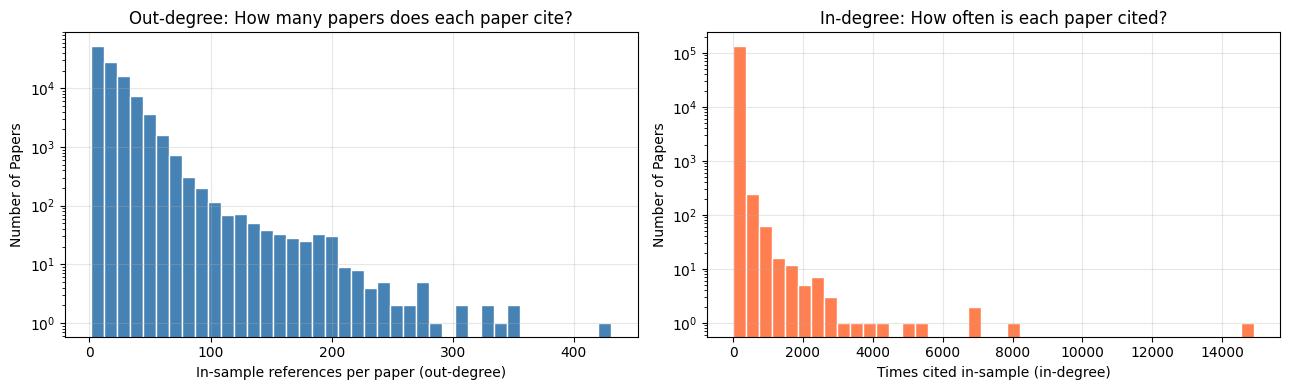

out-degree stats:
count    110989.00
mean         17.21
std          17.57
min           1.00
25%           5.00
50%          12.00
75%          24.00
max         431.00

in-degree stats:
count    132989.00
mean         14.36
std          78.75
min           1.00
25%           2.00
50%           4.00
75%          11.00
max       14911.00


In [37]:
def plot_degree_distributions(df_cit: pd.DataFrame) -> None:
    """
    Side-by-side histograms of in-degree and out-degree.

    I used log scale on the y-axis because citation graphs follow a power law:
    most papers have very few citations and a small number have many. Log scale
    made that long tail visible to us rather than squashing it against zero.
    """
    out_degree = df_cit.groupby("source_id")["target_id"].count()
    in_degree = df_cit.groupby("target_id")["source_id"].count()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(out_degree, bins=40, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("In-sample references per paper (out-degree)")
    axes[0].set_ylabel("Number of Papers")
    axes[0].set_title("Out-degree: How many papers does each paper cite?")
    axes[0].set_yscale("log")
    axes[0].grid(alpha=0.3)

    axes[1].hist(in_degree, bins=40, color="coral", edgecolor="white")
    axes[1].set_xlabel("Times cited in-sample (in-degree)")
    axes[1].set_ylabel("Number of Papers")
    axes[1].set_title("In-degree: How often is each paper cited?")
    axes[1].set_yscale("log")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("out-degree stats:")
    print(out_degree.describe().round(2).to_string())
    print("\nin-degree stats:")
    print(in_degree.describe().round(2).to_string())


plot_degree_distributions(df_cit_f)

In [38]:
def print_top_cited(df_papers: pd.DataFrame, df_cit: pd.DataFrame, top_n: int = 10) -> None:
    """
    Print the top-N most cited papers in the dataset.

    I used this as a sanity check. If I recognized landmark papers like Attention
    Is All You Need near the top, we could trust that the citation data was correct.
    """
    in_counts = df_cit["target_id"].value_counts().head(top_n)
    id_to_title = dict(zip(df_papers["arxiv_id"], df_papers["title"]))

    print(f"top {top_n} most cited papers in this dataset:")
    print("-" * 70)
    for rank, (arxiv_id, count) in enumerate(in_counts.items(), start=1):
        title = id_to_title.get(arxiv_id, "(title not found)")
        print(f"{rank:2}. [{count:4d} citations]  {arxiv_id}")
        print(f"    {title[:80]}")


print_top_cited(df_papers_f, df_cit_f)

top 10 most cited papers in this dataset:
----------------------------------------------------------------------
 1. [14911 citations]  1810.04805
    BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding
 2. [8047 citations]  2005.14165
    Language Models are Few-Shot Learners
 3. [6930 citations]  1912.01703
    PyTorch: An Imperative Style, High-Performance Deep Learning Library
 4. [6728 citations]  2010.11929
    An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale
 5. [5311 citations]  2103.00020
    Learning Transferable Visual Models From Natural Language Supervision
 6. [4853 citations]  1907.11692
    RoBERTa: A Robustly Optimized BERT Pretraining Approach
 7. [4473 citations]  1910.10683
    Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transforme
 8. [3836 citations]  2002.05709
    A Simple Framework for Contrastive Learning of Visual Representations
 9. [3359 citations]  2203.00667
    Generative Ad

In [39]:
# I computed sparsity to understand how much signal the CF models would have.
# More density gives us better collaborative filtering, but citation graphs are
# always very sparse. Typical recommendation datasets sit at 99%+ sparsity.
n_p = len(df_papers_f)
n_c = len(df_cit_f)
density = n_c / (n_p * n_p)
sparsity = 1 - density

print(f"citation matrix size : {n_p:,} x {n_p:,}")
print(f"non-zero entries     : {n_c:,}")
print(f"density              : {density:.6f} ({100*density:.4f}%)")
print(f"sparsity             : {sparsity:.6f} ({100*sparsity:.4f}%)")

citation matrix size : 163,275 x 163,275
non-zero entries     : 1,910,207
density              : 0.000072 (0.0072%)
sparsity             : 0.999928 (99.9928%)


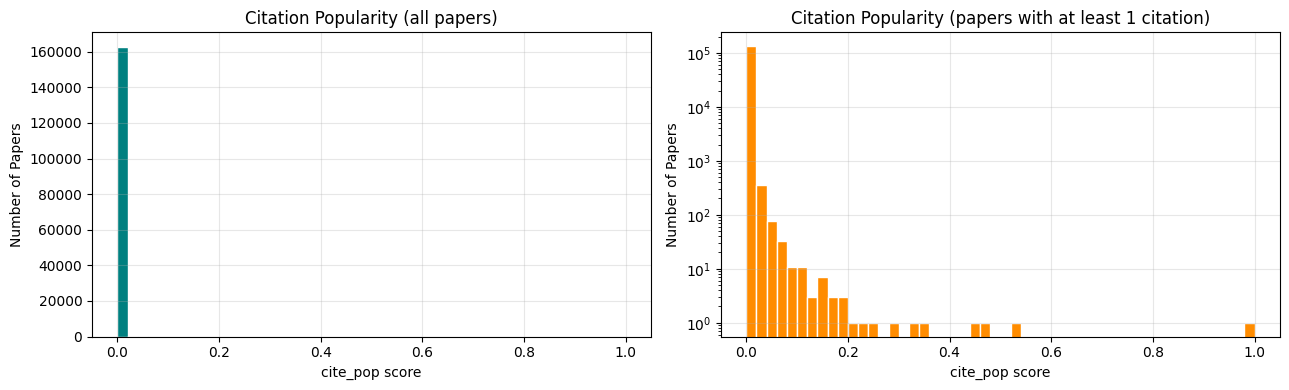

papers with cite_pop = 0 (never cited in-sample): 18.5%


In [40]:
def plot_citation_popularity(df: pd.DataFrame) -> None:
    """Distribution of the cite_pop score (0 to 1). Most papers have low scores."""
    nonzero = df[df["cite_pop"] > 0]["cite_pop"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(df["cite_pop"], bins=50, color="teal", edgecolor="white")
    axes[0].set_xlabel("cite_pop score")
    axes[0].set_ylabel("Number of Papers")
    axes[0].set_title("Citation Popularity (all papers)")
    axes[0].grid(alpha=0.3)

    if len(nonzero) > 0:
        axes[1].hist(nonzero, bins=50, color="darkorange", edgecolor="white")
        axes[1].set_xlabel("cite_pop score")
        axes[1].set_ylabel("Number of Papers")
        axes[1].set_title("Citation Popularity (papers with at least 1 citation)")
        axes[1].set_yscale("log")
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    zero_pct = 100 * (df["cite_pop"] == 0).mean()
    print(f"papers with cite_pop = 0 (never cited in-sample): {zero_pct:.1f}%")


plot_citation_popularity(df_papers_f)

In [41]:
# Final summary card for the dataset.
print("=" * 55)
print(" FINAL DATASET SUMMARY")
print("=" * 55)
print(f"  Papers             : {len(df_papers_f):>8,}")
print(f"  Citation links     : {len(df_cit_f):>8,}")
print(f"  Avg refs/paper     : {len(df_cit_f)/len(df_papers_f):>8.1f}")
print(f"  Matrix density     : {100*density:>8.4f}%")
print(f"  Year range         :   {df_papers_f['year'].min()} - {df_papers_f['year'].max()}")
print(f"  S2 field coverage  : {(df_papers_f['s2_fields'].str.len()>0).mean():>8.1%}")
print(f"  Papers never cited : {(df_papers_f['cite_pop']==0).sum():>8,}")
print("=" * 55)
print()
print("files saved:")
for fname in ["papers.csv", "citations.csv", "citation_pop.csv"]:
    fpath = OUTPUT_DIR / fname
    if fpath.exists():
        size_mb = fpath.stat().st_size / 1e6
        print(f"  {fname:<22} {size_mb:.1f} MB")

 FINAL DATASET SUMMARY
  Papers             :  163,275
  Citation links     : 1,910,207
  Avg refs/paper     :     11.7
  Matrix density     :   0.0072%
  Year range         :   2018 - 2024
  S2 field coverage  :   100.0%
  Papers never cited :   30,286

files saved:
  papers.csv             462.2 MB
  citations.csv          66.2 MB
  citation_pop.csv       4.7 MB


---
## Section 5 - Evaluation Framework

I set up the train/test split and all evaluation logic here once so every model in
Sections 6+ can call `evaluate_model()` with the same held-out test edges and get
numbers that are directly comparable.

**How to evaluate a new model:**
```python
def my_score_fn(query_idx: int) -> np.ndarray:   # shape: (n_papers,)
    ...

evaluate_model("My Model", score_fn=my_score_fn)
compare_models()
```
For models with fast batch scoring (e.g. TF-IDF, matrix factorization), pass
`batch_score_fn(indices: list[int]) -> np.ndarray[B, n_papers]` instead - the
framework automatically uses batched matrix multiplication and logs progress every
batch.

All results accumulate in `MODEL_RESULTS`. Call `compare_models()` at any point
to get a side-by-side table and chart of every model evaluated so far.

In [42]:
from collections import defaultdict

# I split once here with a fixed seed so every model in later sections sees the
# exact same held-out test edges - otherwise metric comparisons would be unfair.
np.random.seed(256)
_edges = df_cit_f[["source_idx", "target_idx"]].values
_perm  = np.random.permutation(len(_edges))
_split = int(0.8 * len(_perm))

_train_edges = _edges[_perm[:_split]]
_test_edges  = _edges[_perm[_split:]]

train_gt: dict[int, set[int]] = defaultdict(set)
test_gt:  dict[int, set[int]] = defaultdict(set)
for _s, _t in _train_edges:
    train_gt[int(_s)].add(int(_t))
for _s, _t in _test_edges:
    test_gt[int(_s)].add(int(_t))

# K values and the fixed query paper list shared across all models
K_VALUES    = [5, 10, 20]
EVAL_SAMPLE = 1_000

_candidates = [s for s, ts in test_gt.items() if len(ts) >= 1]
np.random.seed(42)
np.random.shuffle(_candidates)
EVAL_QUERY_PAPERS = _candidates[:EVAL_SAMPLE]  # same papers evaluated for every model

print(f"train edges  : {len(_train_edges):,}")
print(f"test edges   : {len(_test_edges):,}")
print(f"query papers : {len(EVAL_QUERY_PAPERS):,}  (fixed, seed=42)")

train edges  : 1,528,165
test edges   : 382,042
query papers : 1,000  (fixed, seed=42)


In [81]:
import torch
import numpy as np
import time
from collections import defaultdict

# Registry: model_name -> {k: {metric: value}}
# Every call to evaluate_model() writes here; compare_models() reads from here.
MODEL_RESULTS: dict[str, dict] = {}


# --- metric helpers ---

def _precision_at_k(recs: list, rel: set, k: int) -> float:
    return len(set(recs[:k]) & rel) / k

def _recall_at_k(recs: list, rel: set, k: int) -> float:
    return len(set(recs[:k]) & rel) / len(rel) if rel else 0.0

def _ndcg_at_k(recs: list, rel: set, k: int) -> float:
    dcg  = sum(1.0 / np.log2(i + 2) for i, r in enumerate(recs[:k]) if r in rel)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(k, len(rel))))
    return dcg / idcg if idcg > 0 else 0.0

def _hit_rate_at_k(recs: list, rel: set, k: int) -> float:
    return 1.0 if set(recs[:k]) & rel else 0.0

def _mrr(recs: list, rel: set) -> float:
    for i, r in enumerate(recs):
        if r in rel:
            return 1.0 / (i + 1)
    return 0.0


def evaluate_model(
    name: str,
    score_fn=None,
    batch_score_fn=None,
    batch_size: int = 100,
    k_values: list[int] | None = None,
    query_papers: list[int] | None = None,
) -> dict:
    """
    Evaluate any recommendation model against the shared held-out test set.

    Provide exactly one of:
        score_fn(query_idx: int) -> np.ndarray[n_papers]
            Per-paper scores. Use for models where batch scoring is awkward.
        batch_score_fn(indices: list[int]) -> np.ndarray[B, n_papers]
            Batch scores. Use for TF-IDF, matrix factorization, etc. - much faster.

    The framework handles self-exclusion, train-citation exclusion, top-K ranking
    via argpartition (O(n)), and progress logging automatically.

    Results are stored in MODEL_RESULTS[name] and returned as
    {k: {"Precision", "Recall", "NDCG", "Hit Rate", "MRR"}}.
    """
    if k_values is None:
        k_values = K_VALUES
    if query_papers is None:
        query_papers = EVAL_QUERY_PAPERS
    k_max  = max(k_values)
    n_eval = len(query_papers)
    ref_k  = 10 if 10 in k_values else k_values[-1]

    bucket = {k: {"p": [], "r": [], "ndcg": [], "hr": [], "mrr": []} for k in k_values}

    print(f"\n{'='*55}")
    print(f"  evaluating : {name}")
    print(f"  queries    : {n_eval:,}  |  K = {k_values}")
    print(f"{'='*55}")
    t0 = time.monotonic()

    def _rank(q_idx: int, scores: np.ndarray) -> list[int]:
        scores = scores.copy()
        scores[q_idx] = -np.inf
        for excl in train_gt.get(q_idx, set()):
            if excl < len(scores):
                scores[excl] = -np.inf
        top_part = np.argpartition(scores, -k_max)[-k_max:]
        return top_part[np.argsort(scores[top_part])[::-1]].tolist()

    def _accumulate(q_idx: int, recs: list[int]) -> None:
        rel = test_gt[q_idx]
        for k in k_values:
            bucket[k]["p"].append(_precision_at_k(recs, rel, k))
            bucket[k]["r"].append(_recall_at_k(recs, rel, k))
            bucket[k]["ndcg"].append(_ndcg_at_k(recs, rel, k))
            bucket[k]["hr"].append(_hit_rate_at_k(recs, rel, k))
            bucket[k]["mrr"].append(_mrr(recs[:k], rel))

    def _log(done: int) -> None:
        elapsed = time.monotonic() - t0
        rate    = done / elapsed if elapsed > 0 else 0
        eta     = (n_eval - done) / rate if rate > 0 else 0
        p   = np.mean(bucket[ref_k]["p"])  if bucket[ref_k]["p"]  else 0.0
        hr  = np.mean(bucket[ref_k]["hr"]) if bucket[ref_k]["hr"] else 0.0
        print(f"  [{done:>4}/{n_eval}]  {elapsed:5.1f}s  |  "
              f"ETA {eta:4.0f}s  |  P@{ref_k}={p:.4f}  HR@{ref_k}={hr:.4f}")

    if batch_score_fn is not None:
        for start in range(0, n_eval, batch_size):
            batch = query_papers[start : start + batch_size]
            batch_scores = batch_score_fn(batch)          # (B, n_papers)
            for j, q_idx in enumerate(batch):
                _accumulate(q_idx, _rank(q_idx, batch_scores[j]))
            _log(min(start + batch_size, n_eval))
    else:
        for i, q_idx in enumerate(query_papers):
            _accumulate(q_idx, _rank(q_idx, score_fn(q_idx)))
            if (i + 1) % 100 == 0 or (i + 1) == n_eval:
                _log(i + 1)

    elapsed = time.monotonic() - t0
    result = {
        k: {
            "Precision": np.mean(bucket[k]["p"]),
            "Recall":    np.mean(bucket[k]["r"]),
            "NDCG":      np.mean(bucket[k]["ndcg"]),
            "Hit Rate":  np.mean(bucket[k]["hr"]),
            "MRR":       np.mean(bucket[k]["mrr"]),
        }
        for k in k_values
    }
    MODEL_RESULTS[name] = result
    print(f"\n  done in {elapsed:.1f}s  ({1000*elapsed/n_eval:.0f} ms/paper)")
    print(f"  stored → MODEL_RESULTS['{name}']")
    return result


def compare_models(
    model_results: dict | None = None,
    k_values: list[int] | None = None,
    plot_k: int = 10,
) -> None:
    """
    Print a side-by-side comparison table and chart for all registered models.

    Args:
        model_results: Defaults to the global MODEL_RESULTS registry.
        k_values: K values shown in the table. Defaults to K_VALUES.
        plot_k: Which K to use for the grouped bar chart. Defaults to 10.
    """
    if model_results is None:
        model_results = MODEL_RESULTS
    if k_values is None:
        k_values = K_VALUES
    if not model_results:
        print("no models registered yet - run evaluate_model() first")
        return

    models  = list(model_results.keys())
    metrics = ["Precision", "Recall", "NDCG", "Hit Rate", "MRR"]
    col_w   = max(12, max(len(m) for m in models) + 2)

    # --- comparison table: rows = metrics, columns = models (at plot_k) ---
    print(f"\nModel Comparison  @K={plot_k}")
    print("=" * (18 + col_w * len(models)))
    print(f"{'Metric':<18}" + "".join(f"{m:>{col_w}}" for m in models))
    print("-" * (18 + col_w * len(models)))
    for metric in metrics:
        row = f"{metric:<18}"
        for m in models:
            val = model_results[m].get(plot_k, {}).get(metric, float("nan"))
            row += f"{val:>{col_w}.4f}"
        print(row)
    print("=" * (18 + col_w * len(models)))

    # --- full table across all K values ---
    print(f"\nFull table across K = {k_values}")
    max_model_name_len = max(len(m) for m in models)
    # Each column will be 'ModelName@K'. Let's set a consistent width including padding.
    # For instance, if max_model_name_len is 15, 'ModelName@10' is 18 chars. Add 2 padding for 20.
    column_display_width = max_model_name_len + max(len(str(k)) for k in k_values) + 3 # +3 for '@' and padding

    # Header for the full table
    header_parts = [f"{'Metric':<{column_display_width}}"]
    for k in k_values:
        for mn in models:
            header_parts.append(f"{mn[:max_model_name_len]}@{k:<2}")
    print("-" * (len("  ".join(header_parts)) + 2))
    print("  ".join(header_parts))
    print("-" * (len("  ".join(header_parts)) + 2))

    for metric in metrics:
        row_parts = [f"{metric:<{column_display_width}}"]
        for k in k_values:
            for mn in models:
                val = model_results[mn].get(k, {}).get(metric, float("nan"))
                row_parts.append(f"{val:>{max_model_name_len+3}.4f}") # Use max_model_name_len+3 for value alignment
        print("  ".join(row_parts))

    # --- plots ---
    colors = plt.cm.tab10.colors
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # grouped bar chart at plot_k
    key_metrics = ["Precision", "NDCG", "Hit Rate", "MRR"]
    x     = np.arange(len(key_metrics))
    width = min(0.6, 0.8 / max(len(models), 1))
    for i, mn in enumerate(models):
        vals   = [model_results[mn].get(plot_k, {}).get(m, 0) for m in key_metrics]
        offset = (i - len(models) / 2 + 0.5) * width
        bars   = ax1.bar(x + offset, vals, width, label=mn,
                         color=colors[i % 10], edgecolor="white")
        for bar, v in zip(bars, vals):
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                     f"{v:.3f}", ha="center", va="bottom", fontsize=7.5, rotation=40)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{m}@{plot_k}" for m in key_metrics])
    ax1.set_ylabel("Score")
    ax1.set_title(f"Model Comparison @ K={plot_k}")
    ax1.legend(loc="upper right", fontsize=8)
    ax1.grid(axis="y", alpha=0.3)
    ax1.set_ylim(bottom=0)

    # Precision@K curves per model
    for i, mn in enumerate(models):
        ks = sorted(k_values)
        ps = [model_results[mn].get(k, {}).get("Precision", 0) for k in ks]
        ax2.plot(ks, ps, marker="o", label=mn, color=colors[i % 10], linewidth=2.5)
    ax2.set_xlabel("K")
    ax2.set_ylabel("Precision@K")
    ax2.set_title("Precision@K Curves")
    ax2.set_xticks(k_values)
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)
    ax2.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("saved → model_comparison.png")


print("evaluation framework ready")
print(f"  MODEL_RESULTS  : registry for all model results")
print(f"  evaluate_model : run evaluation for any model")
print(f"  compare_models : side-by-side table + chart")

evaluation framework ready
  MODEL_RESULTS  : registry for all model results
  evaluate_model : run evaluation for any model
  compare_models : side-by-side table + chart


---
## Section 6 - Baseline Model: TF-IDF Content Similarity

I built a TF-IDF cosine similarity baseline to quantify how much citation-structure
information the graph-based CF models add over pure content matching.

**Approach:** Vectorize each paper's `text` field (title × 2 + abstract) with TF-IDF,
then rank all other papers by cosine similarity. Because the vectors are l2-normalised,
dot product equals cosine similarity - no explicit division needed.

**Why this baseline:** If TF-IDF already achieves high Precision@K, vocabulary overlap
alone explains citation structure. If scores are low, there is headroom for collaborative
filtering models to improve by exploiting co-citation patterns that text misses.

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

# I used 50k features to balance vocabulary coverage with memory footprint.
# sublinear_tf=True applies log(1+tf) to dampen very frequent terms.
# min_df=3 drops terms appearing in fewer than 3 papers (noise / typos).
# Bigrams (1,2) capture phrases like "neural network" and "language model".
# norm="l2" means each row has unit norm, so dot product equals cosine similarity.
vectorizer = TfidfVectorizer(
    max_features=50_000,
    min_df=3,
    ngram_range=(1, 2),
    sublinear_tf=True,
    norm="l2",
)
tfidf_matrix = vectorizer.fit_transform(df_papers_f["text"].fillna(""))

print(f"TF-IDF matrix : {tfidf_matrix.shape[0]:,} papers × {tfidf_matrix.shape[1]:,} terms")
print(f"non-zeros     : {tfidf_matrix.nnz:,}")
print(f"sparsity      : {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4%}")

TF-IDF matrix : 163,275 papers × 50,000 terms
non-zeros     : 33,836,291
sparsity      : 99.5855%


In [45]:
import pickle
import scipy.sparse as sp

_vec_path = OUTPUT_DIR / "tfidf_vectorizer.pkl"
_mat_path = OUTPUT_DIR / "tfidf_matrix.npz"

with open(_vec_path, "wb") as _f:
    pickle.dump(vectorizer, _f)
sp.save_npz(_mat_path, tfidf_matrix)

print(f"saved tfidf_vectorizer.pkl  ({_vec_path.stat().st_size / 1e6:.1f} MB)")
print(f"saved tfidf_matrix.npz      ({_mat_path.stat().st_size / 1e6:.1f} MB)")


saved tfidf_vectorizer.pkl  (2.1 MB)
saved tfidf_matrix.npz      (324.7 MB)


In [46]:
def _tfidf_batch_score(indices: list[int]) -> np.ndarray:
    """Batch cosine similarities via sparse matmul. rows are l2-norm so dot = cosine."""
    return (tfidf_matrix[indices] @ tfidf_matrix.T).toarray()

tfidf_results = evaluate_model(
    "TF-IDF",
    batch_score_fn=_tfidf_batch_score,
    batch_size=100,
)


  evaluating : TF-IDF
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]    3.0s  |  ETA   27s  |  P@10=0.0350  HR@10=0.3000
  [ 200/1000]    5.6s  |  ETA   22s  |  P@10=0.0330  HR@10=0.2850
  [ 300/1000]    8.1s  |  ETA   19s  |  P@10=0.0323  HR@10=0.2767
  [ 400/1000]   11.3s  |  ETA   17s  |  P@10=0.0300  HR@10=0.2525
  [ 500/1000]   14.4s  |  ETA   14s  |  P@10=0.0308  HR@10=0.2520
  [ 600/1000]   17.3s  |  ETA   12s  |  P@10=0.0328  HR@10=0.2633
  [ 700/1000]   19.9s  |  ETA    9s  |  P@10=0.0326  HR@10=0.2643
  [ 800/1000]   22.5s  |  ETA    6s  |  P@10=0.0340  HR@10=0.2750
  [ 900/1000]   25.0s  |  ETA    3s  |  P@10=0.0328  HR@10=0.2667
  [1000/1000]   27.8s  |  ETA    0s  |  P@10=0.0324  HR@10=0.2620

  done in 27.8s  (28 ms/paper)
  stored → MODEL_RESULTS['TF-IDF']


In [82]:
compare_models()

no models registered yet - run evaluate_model() first


In [48]:
from IPython.display import Markdown, display

# I generated this narrative programmatically so every label and number
# reflects the actual run output rather than hard-coded prose.
_r = MODEL_RESULTS["TF-IDF"]

n_papers   = len(df_papers_f)
random_p10 = 10 / n_papers
lift       = _r[10]["Precision"] / random_p10 if random_p10 > 0 else 0

p5,  p10,  p20  = _r[5]["Precision"], _r[10]["Precision"], _r[20]["Precision"]
r10             = _r[10]["Recall"]
nd10            = _r[10]["NDCG"]
hr10            = _r[10]["Hit Rate"]
mr10            = _r[10]["MRR"]

def _band(val, low, mid):
    return "strong" if val >= mid else ("moderate" if val >= low else "low")

p_band    = _band(p10,  0.01, 0.05)
hr_band   = _band(hr10, 0.15, 0.35)
ndcg_band = _band(nd10, 0.05, 0.15)

avg_rank  = f"~{int(round(1/mr10))}" if mr10 > 0 else "outside top-K"
mrr_line  = (
    f"The first true citation surfaces at rank **{avg_rank}** on average (MRR@10 = {mr10:.4f})."
    if mr10 > 0 else
    f"MRR@10 = {mr10:.4f} - no true citations reached the top-K for most queries."
)

p_trend = "flat" if abs(p20 - p5) < 0.005 else ("falling" if p20 < p5 else "rising")
trend_note = {
    "flat":    f"Precision is nearly flat across K ({p5:.4f} → {p20:.4f}), meaning true citations are spread evenly rather than concentrated at the top.",
    "falling": f"Precision falls as K grows ({p5:.4f} → {p20:.4f}), which is expected - the top slots are cleaner than the top-20.",
    "rising":  f"Precision rises with K ({p5:.4f} → {p20:.4f}), suggesting true citations are spread throughout the list rather than clustered at the top.",
}[p_trend]

headroom = (
    "The baseline is already capturing meaningful content signal - CF models will need strong structural evidence to improve further."
    if p10 > 0.05 else
    "The baseline leaves substantial room for improvement - graph-based CF models should gain significantly by exploiting co-citation patterns that text alone misses."
)

display(Markdown(f"""---
### TF-IDF Baseline - Findings

**Precision@10 = {p10:.4f}** *({p_band})* - roughly **{p10*10:.1f} out of every 10**
recommendations are real citations. A random recommender on this {n_papers:,}-paper corpus
would achieve Precision@10 ≈ {random_p10:.5f}, so TF-IDF delivers a **{lift:.0f}× lift
over random**, confirming that vocabulary overlap does carry real citation signal.

**Hit Rate@10 = {hr10:.4f}** *({hr_band})* - at least one true citation appears in the
top-10 for **{hr10*100:.1f}%** of queries.
{"Solid coverage for a content-only model." if hr_band != "low" else "Lower than expected - the citation graph likely encodes structure vocabulary overlap cannot capture."}

**NDCG@10 = {nd10:.4f}** *({ndcg_band})* -
{"True citations tend to appear near the top of the ranked list." if nd10 > 0.10 else "True citations are found but not consistently ranked near the top."}

**{mrr_line}**

**Recall@10 = {r10:.4f}** - we recover {r10*100:.1f}% of each paper's true citations in
the top-10. Expected to be low since papers cite 20–40 others and we retrieve only 10.

{trend_note}

#### What this means for the CF models

{headroom} Any model beating **Precision@10 > {p10:.4f}** and **NDCG@10 > {nd10:.4f}**
represents a measurable gain from structural co-citation signal beyond what text provides.
---"""))

---
### TF-IDF Baseline - Findings

**Precision@10 = 0.0324** *(moderate)* - roughly **0.3 out of every 10**
recommendations are real citations. A random recommender on this 163,275-paper corpus
would achieve Precision@10 ≈ 0.00006, so TF-IDF delivers a **529× lift
over random**, confirming that vocabulary overlap does carry real citation signal.

**Hit Rate@10 = 0.2620** *(moderate)* - at least one true citation appears in the
top-10 for **26.2%** of queries.
Solid coverage for a content-only model.

**NDCG@10 = 0.0800** *(moderate)* -
True citations are found but not consistently ranked near the top.

**The first true citation surfaces at rank **~8** on average (MRR@10 = 0.1228).**

**Recall@10 = 0.1026** - we recover 10.3% of each paper's true citations in
the top-10. Expected to be low since papers cite 20–40 others and we retrieve only 10.

Precision falls as K grows (0.0434 → 0.0238), which is expected - the top slots are cleaner than the top-20.

#### What this means for the CF models

The baseline leaves substantial room for improvement - graph-based CF models should gain significantly by exploiting co-citation patterns that text alone misses. Any model beating **Precision@10 > 0.0324** and **NDCG@10 > 0.0800**
represents a measurable gain from structural co-citation signal beyond what text provides.
---

In [49]:
# I picked a random paper and showed what TF-IDF recommends for it.
# Recognising relevant papers in the top-10 is a quick sanity check that the
# model is doing something sensible before we look at aggregate metrics.
np.random.seed(42)
sample_idx = int(np.random.choice(df_papers_f["paper_idx"].values))
sample_row = df_papers_f.set_index("paper_idx").loc[sample_idx]

print("Query paper:")
print(f"  arXiv ID : {sample_row['arxiv_id']}")
print(f"  Year     : {sample_row['year']}")
print(f"  Category : {sample_row['primary_cat']}")
print(f"  Title    : {sample_row['title'][:100]}")
print()

scores = (tfidf_matrix[sample_idx] @ tfidf_matrix.T).toarray().ravel()
scores[sample_idx] = -np.inf  # exclude self
top10_idx = np.argsort(scores)[::-1][:10]

id_to_row = df_papers_f.set_index("paper_idx")
actual_citations = set(df_cit_f[df_cit_f["source_idx"] == sample_idx]["target_idx"])

print("Top-10 TF-IDF recommendations  (* = actual citation in dataset):")
print("-" * 72)
for rank, idx in enumerate(top10_idx, start=1):
    row  = id_to_row.loc[idx]
    sim  = scores[idx]
    flag = " *" if idx in actual_citations else ""
    print(f"{rank:2}.{flag} [sim={sim:.3f}] {row['arxiv_id']} ({row['year']}, {row['primary_cat']})")
    print(f"     {row['title'][:80]}")

Query paper:
  arXiv ID : 2305.12420
  Year     : 2023
  Category : cs.IR
  Title    : Multi-factor Sequential Re-ranking with Perception-Aware Diversification

Top-10 TF-IDF recommendations  (* = actual citation in dataset):
------------------------------------------------------------------------
 1. [sim=0.235] 2107.05204 (2021, cs.IR)
     Sliding Spectrum Decomposition for Diversified Recommendation
 2. [sim=0.231] 2203.12267 (2022, cs.IR)
     PEAR: Personalized Re-ranking with Contextualized Transformer for Recommendation
 3. [sim=0.222] 2206.05020 (2022, cs.IR)
     Feature-aware Diversified Re-ranking with Disentangled Representations for Relev
 4. [sim=0.220] 2112.07621 (2021, cs.IR)
     Re-ranking With Constraints on Diversified Exposures for Homepage Recommender Sy
 5. [sim=0.208] 1904.06813 (2019, cs.IR)
     Personalized Re-ranking for Recommendation
 6. [sim=0.197] 1908.10171 (2019, cs.IR)
     Improving End-to-End Sequential Recommendations with Intent-aware Diversifica

## Section 7: Advanced Models

### SVD:
- "User" is the source paper and the "Item" is the cited paper
- rows: Your original paper_id list (The "Seekers")
- cols: The unique cited_paper_id list (The "References")
- values: binary (1 if a citation exists, 0 otherwise)
- By decomposing this matrix, SVD finds "Latent Factors."
- If Paper A and Paper B cite many of the same things, they will have similar vectors in the latent space. This allows you to recommend a paper that Paper A should have cited because it fits the mathematical "neighborhood" of its other citations.
- Using truncatedSVD since our matrix is huge, so its limited to 128 fac, can increase if needed.
- this model good for sparse matrices from what i can see; also surprise svd better for user x item rating preds rather than the way we r using, cuz 1 = citation exist and 0 unkwown

SVD Matrix set up...
citation matrix shape : (163275, 163275)
non-zeros             : 1,528,165
done in 17.3s
embedding shape : (163275, 128)

evaluating on 1,000 query papers ...
  [ 100/1000]    1.6s elapsed  |  ETA   14s  |  P@10=0.0050  HR@10=0.0500
  [ 200/1000]    3.0s elapsed  |  ETA   12s  |  P@10=0.0050  HR@10=0.0500
  [ 300/1000]    4.5s elapsed  |  ETA   11s  |  P@10=0.0053  HR@10=0.0533
  [ 400/1000]    6.0s elapsed  |  ETA    9s  |  P@10=0.0048  HR@10=0.0475
  [ 500/1000]    7.6s elapsed  |  ETA    8s  |  P@10=0.0040  HR@10=0.0400
  [ 600/1000]   10.4s elapsed  |  ETA    7s  |  P@10=0.0037  HR@10=0.0367
  [ 700/1000]   13.0s elapsed  |  ETA    6s  |  P@10=0.0037  HR@10=0.0371
  [ 800/1000]   14.6s elapsed  |  ETA    4s  |  P@10=0.0039  HR@10=0.0387
  [ 900/1000]   16.2s elapsed  |  ETA    2s  |  P@10=0.0040  HR@10=0.0389
  [1000/1000]   17.7s elapsed  |  ETA    0s  |  P@10=0.0043  HR@10=0.0400
Results of test values in table format...

done in 17.7s

SVD Citation Recommend

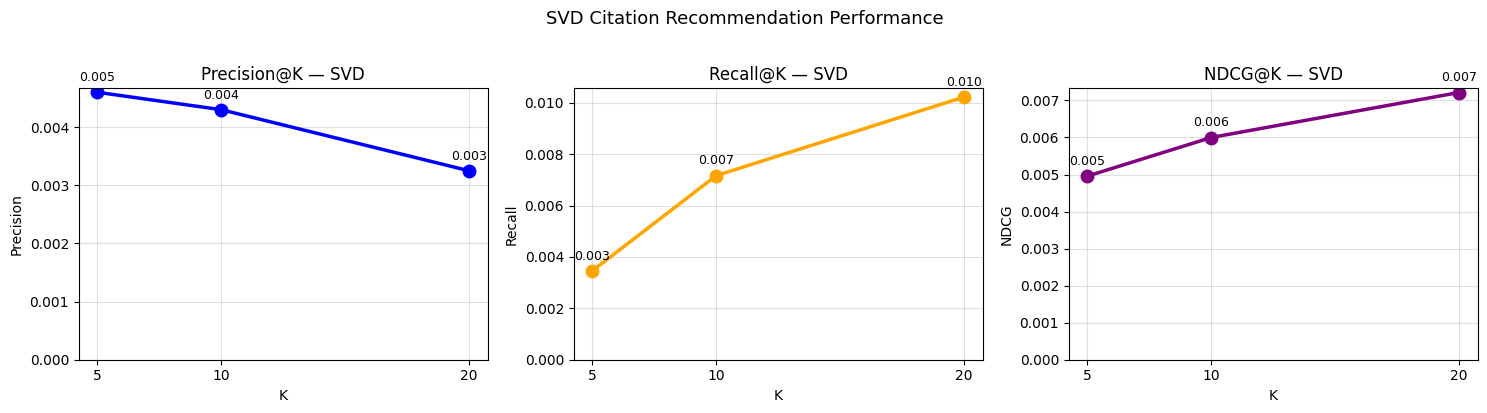

In [50]:
## SVD Citation Recommender:

print('SVD Matrix set up...')

n_papers = len(df_papers_f)

A_train = csr_matrix((np.ones(len(_train_edges), dtype=np.float32),(_train_edges[:, 0], _train_edges[:, 1])),shape=(n_papers, n_papers))

print(f"citation matrix shape : {A_train.shape}")
print(f"non-zeros             : {A_train.nnz:,}")

## train SVD model
N_COMPONENTS = 128

t0 = time.monotonic()

svd = TruncatedSVD(n_components=N_COMPONENTS,random_state=256)

paper_embeddings = svd.fit_transform(A_train)

elapsed = time.monotonic() - t0

print(f"done in {elapsed:.1f}s")
print(f"embedding shape : {paper_embeddings.shape}")

# ---- eval ----
#eval
query_papers = [src for src, tgts in test_gt.items() if len(tgts) >= 1]
np.random.shuffle(query_papers)

EVAL_SAMPLE = min(1_000, len(query_papers))
query_papers = query_papers[:EVAL_SAMPLE]

print(f"\nevaluating on {EVAL_SAMPLE:,} query papers ...")

bucket = {
    k: {"p": [], "r": [], "ndcg": [], "hr": [], "mrr": []}
    for k in K_VALUES
}

LOG_EVERY = 100
K_VALUES = [5, 10, 20]
K_MAX = max(K_VALUES)

t0 = time.monotonic()

for i, q_idx in enumerate(query_papers):
    #latent sim scores
    scores = paper_embeddings[q_idx] @ paper_embeddings.T

    #exclude self
    scores[q_idx] = -np.inf

    #exclude training citations
    for excl in train_gt.get(q_idx, set()):
        if excl < len(scores):
            scores[excl] = -np.inf

    #top k reccs
    recs = np.argsort(scores)[::-1][:K_MAX].tolist()

    rel = test_gt[q_idx]

    for k in K_VALUES:
        bucket[k]["p"].append(_precision_at_k(recs, rel, k))
        bucket[k]["r"].append(_recall_at_k(recs, rel, k))
        bucket[k]["ndcg"].append(_ndcg_at_k(recs, rel, k))
        bucket[k]["hr"].append(_hit_rate_at_k(recs, rel, k))
        bucket[k]["mrr"].append(_mrr(recs[:k], rel))

    if (i + 1) % LOG_EVERY == 0 or (i + 1) == EVAL_SAMPLE:

        elapsed = time.monotonic() - t0
        rate = (i + 1) / elapsed
        eta_s = (EVAL_SAMPLE - i - 1) / rate if rate > 0 else 0

        p10 = np.mean(bucket[10]["p"])
        hr10 = np.mean(bucket[10]["hr"])

        print(
            f"  [{i+1:>4}/{EVAL_SAMPLE}]  "
            f"{elapsed:5.1f}s elapsed  |  "
            f"ETA {eta_s:4.0f}s  |  "
            f"P@10={p10:.4f}  HR@10={hr10:.4f}"
        )

#---table---
#results
print('Results of test values in table format...')
results_svd = {
    k: {
        "Precision": np.mean(bucket[k]["p"]),
        "Recall":    np.mean(bucket[k]["r"]),
        "NDCG":      np.mean(bucket[k]["ndcg"]),
        "Hit Rate":  np.mean(bucket[k]["hr"]),
        "MRR":       np.mean(bucket[k]["mrr"]),
    }
    for k in K_VALUES
}

total_elapsed = time.monotonic() - t0

print(f"\ndone in {total_elapsed:.1f}s")

#table across @ k
print("\nSVD Citation Recommender — Evaluation Results")
print("=" * 58)

header = f"{'Metric':<14}" + "".join(f"{'@'+str(k):>12}" for k in K_VALUES)
print(header)

print("-" * 58)

for metric in ["Precision", "Recall", "NDCG", "Hit Rate", "MRR"]:
    row = f"{metric:<14}" + "".join(
        f"{results_svd[k][metric]:>12.4f}" for k in K_VALUES
    )
    print(row)

print("=" * 58)

#---plots---

#plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metric_colors = [
    ("Precision", "blue"),
    ("Recall", "orange"),
    ("NDCG", "purple")
]

for ax, (metric, color) in zip(axes, metric_colors):

    vals = [results_svd[k][metric] for k in K_VALUES]

    ax.plot(
        K_VALUES,
        vals,
        marker="o",
        linewidth=2.5,
        color=color,
        markersize=9
    )

    for k, v in zip(K_VALUES, vals):
        ax.annotate(
            f"{v:.3f}",
            (k, v),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9
        )

    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K — SVD")
    ax.set_xticks(K_VALUES)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.4)

plt.suptitle("SVD Citation Recommendation Performance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [83]:
compare_models()

no models registered yet - run evaluate_model() first


### PageRank & Personlized PageRank w MonteCarlo

- directed acyclic Graph/ dag
— Nodes: Every unique arXiv ID (both sources and targets).
- Edges: A directed arrow from paper_id --> cited_paper_id.
- logic/why it applies here: (In-Degree): How many papers cite this paper? (Standard popularity).
- PageRank: A paper is "important" if it is cited by other important papers.
- why PPR vs standard PR: Standard PR might just give you "famous" papers, while PPR restarts frequently at query paper and focuses on important relative to that paper --> this should help w cross-domain aspect

### ppr

Pagerank set up...
nodes : 162,069
edges : 1,528,165
done in 3.1s

evaluating on 1,000 query papers ...
  [ 100/1000]    0.6s elapsed  |  ETA    6s  |  P@10=0.0150  HR@10=0.1400
  [ 200/1000]    1.3s elapsed  |  ETA    5s  |  P@10=0.0115  HR@10=0.1100
  [ 300/1000]    1.9s elapsed  |  ETA    4s  |  P@10=0.0110  HR@10=0.1033
  [ 400/1000]    2.5s elapsed  |  ETA    4s  |  P@10=0.0130  HR@10=0.1225
  [ 500/1000]    3.2s elapsed  |  ETA    3s  |  P@10=0.0120  HR@10=0.1120
  [ 600/1000]    3.8s elapsed  |  ETA    3s  |  P@10=0.0112  HR@10=0.1050
  [ 700/1000]    4.4s elapsed  |  ETA    2s  |  P@10=0.0107  HR@10=0.1000
  [ 800/1000]    5.1s elapsed  |  ETA    1s  |  P@10=0.0105  HR@10=0.0988
  [ 900/1000]    5.7s elapsed  |  ETA    1s  |  P@10=0.0107  HR@10=0.1000
  [1000/1000]    6.3s elapsed  |  ETA    0s  |  P@10=0.0105  HR@10=0.0980

done in 6.3s

PageRank Citation Baseline — Evaluation Results
Metric                  @5         @10         @20
------------------------------------------

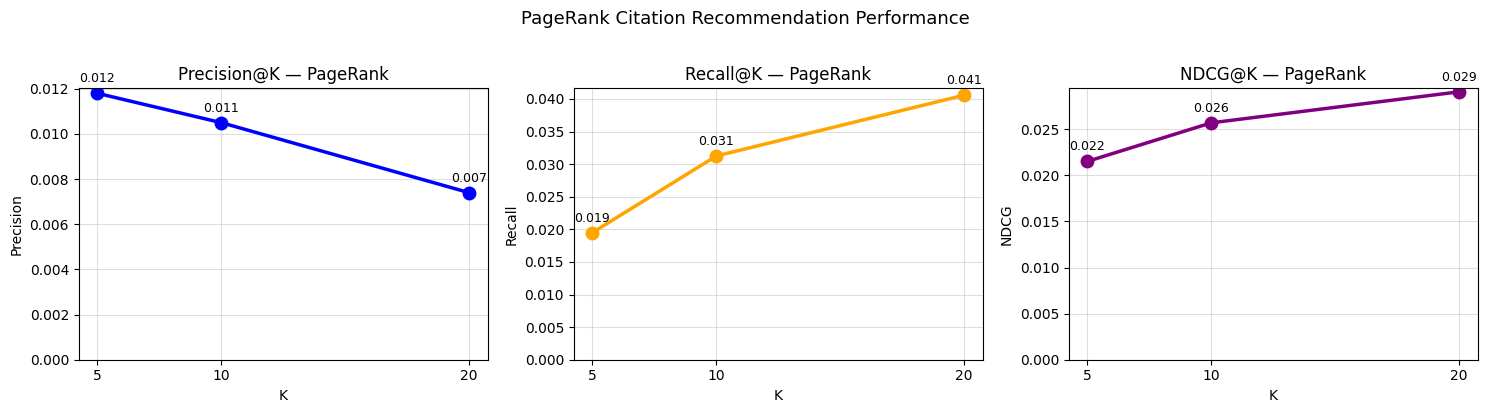

In [51]:
# standard pagerank algo

#citation graph
print("Pagerank set up...")
G = nx.DiGraph()
G.add_edges_from(_train_edges)

print(f"nodes : {G.number_of_nodes():,}")
print(f"edges : {G.number_of_edges():,}")

#pagerank
t0 = time.monotonic()

#using the dampening param
pr_scores = nx.pagerank(G,alpha=0.85)

elapsed = time.monotonic() - t0

print(f"done in {elapsed:.1f}s")

#pagerank dict to numpy array
n_papers = len(df_papers_f)

pagerank_vector = np.zeros(n_papers, dtype=np.float32)

for idx, score in pr_scores.items():
    if idx < n_papers:
        pagerank_vector[idx] = score

#----eval----
#evaluation for a random paper
query_papers = [src for src, tgts in test_gt.items() if len(tgts) >= 1]
np.random.shuffle(query_papers)

EVAL_SAMPLE = min(1_000, len(query_papers))
query_papers = query_papers[:EVAL_SAMPLE]

print(f"\nevaluating on {EVAL_SAMPLE:,} query papers ...")

bucket = {
    k: {"p": [], "r": [], "ndcg": [], "hr": [], "mrr": []}
    for k in K_VALUES
}

LOG_EVERY = 100
t0 = time.monotonic()

for i, q_idx in enumerate(query_papers):
    scores = pagerank_vector.copy()

    #exclude self
    scores[q_idx] = -np.inf

    #exclude training ciations
    for excl in train_gt.get(q_idx, set()):
        if excl < len(scores):
            scores[excl] = -np.inf

    #top k recommendations
    recs = np.argsort(scores)[::-1][:K_MAX].tolist()

    rel = test_gt[q_idx]

    for k in K_VALUES:
        bucket[k]["p"].append(_precision_at_k(recs, rel, k))
        bucket[k]["r"].append(_recall_at_k(recs, rel, k))
        bucket[k]["ndcg"].append(_ndcg_at_k(recs, rel, k))
        bucket[k]["hr"].append(_hit_rate_at_k(recs, rel, k))
        bucket[k]["mrr"].append(_mrr(recs[:k], rel))

    if (i + 1) % LOG_EVERY == 0 or (i + 1) == EVAL_SAMPLE:

        elapsed = time.monotonic() - t0
        rate = (i + 1) / elapsed
        eta_s = (EVAL_SAMPLE - i - 1) / rate if rate > 0 else 0

        p10 = np.mean(bucket[10]["p"])
        hr10 = np.mean(bucket[10]["hr"])

        print(
            f"  [{i+1:>4}/{EVAL_SAMPLE}]  "
            f"{elapsed:5.1f}s elapsed  |  "
            f"ETA {eta_s:4.0f}s  |  "
            f"P@10={p10:.4f}  HR@10={hr10:.4f}"
        )
#---results---
#results
results_pr = {
    k: {
        "Precision": np.mean(bucket[k]["p"]),
        "Recall":    np.mean(bucket[k]["r"]),
        "NDCG":      np.mean(bucket[k]["ndcg"]),
        "Hit Rate":  np.mean(bucket[k]["hr"]),
        "MRR":       np.mean(bucket[k]["mrr"]),
    }
    for k in K_VALUES
}

total_elapsed = time.monotonic() - t0

print(f"\ndone in {total_elapsed:.1f}s")

#----table of results----
#table across @k
print("\nPageRank Citation Baseline — Evaluation Results")
print("=" * 58)

header = f"{'Metric':<14}" + "".join(f"{'@'+str(k):>12}" for k in K_VALUES)
print(header)

print("-" * 58)

for metric in ["Precision", "Recall", "NDCG", "Hit Rate", "MRR"]:
    row = f"{metric:<14}" + "".join(
        f"{results_pr[k][metric]:>12.4f}" for k in K_VALUES
    )
    print(row)

print("=" * 58)

#----plots----
#plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metric_colors = [
    ("Precision", "blue"),
    ("Recall", "orange"),
    ("NDCG", "purple")
]

for ax, (metric, color) in zip(axes, metric_colors):

    vals = [results_pr[k][metric] for k in K_VALUES]

    ax.plot(
        K_VALUES,
        vals,
        marker="o",
        linewidth=2.5,
        color=color,
        markersize=9
    )

    for k, v in zip(K_VALUES, vals):
        ax.annotate(
            f"{v:.3f}",
            (k, v),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9
        )

    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K — PageRank")
    ax.set_xticks(K_VALUES)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.4)

plt.suptitle("PageRank Citation Recommendation Performance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [84]:
compare_models()

no models registered yet - run evaluate_model() first


### PPR Montecarlo

Setting up PPR Montecarlo
graph nodes: 163,275

evaluating on 1,000 query papers ...
  [  25/1000]    0.4s elapsed  |  ETA   15s  |  P@10=0.0520  HR@10=0.3600
  [  50/1000]    0.8s elapsed  |  ETA   15s  |  P@10=0.0520  HR@10=0.3600
  [  75/1000]    1.2s elapsed  |  ETA   15s  |  P@10=0.0480  HR@10=0.3333
  [ 100/1000]    1.6s elapsed  |  ETA   14s  |  P@10=0.0550  HR@10=0.3800
  [ 125/1000]    2.0s elapsed  |  ETA   14s  |  P@10=0.0520  HR@10=0.3600
  [ 150/1000]    2.4s elapsed  |  ETA   14s  |  P@10=0.0493  HR@10=0.3467
  [ 175/1000]    2.6s elapsed  |  ETA   12s  |  P@10=0.0480  HR@10=0.3429
  [ 200/1000]    2.9s elapsed  |  ETA   12s  |  P@10=0.0490  HR@10=0.3450
  [ 225/1000]    3.1s elapsed  |  ETA   11s  |  P@10=0.0476  HR@10=0.3422
  [ 250/1000]    3.4s elapsed  |  ETA   10s  |  P@10=0.0456  HR@10=0.3320
  [ 275/1000]    3.6s elapsed  |  ETA   10s  |  P@10=0.0451  HR@10=0.3236
  [ 300/1000]    3.8s elapsed  |  ETA    9s  |  P@10=0.0437  HR@10=0.3167
  [ 325/1000]    4.1s elaps

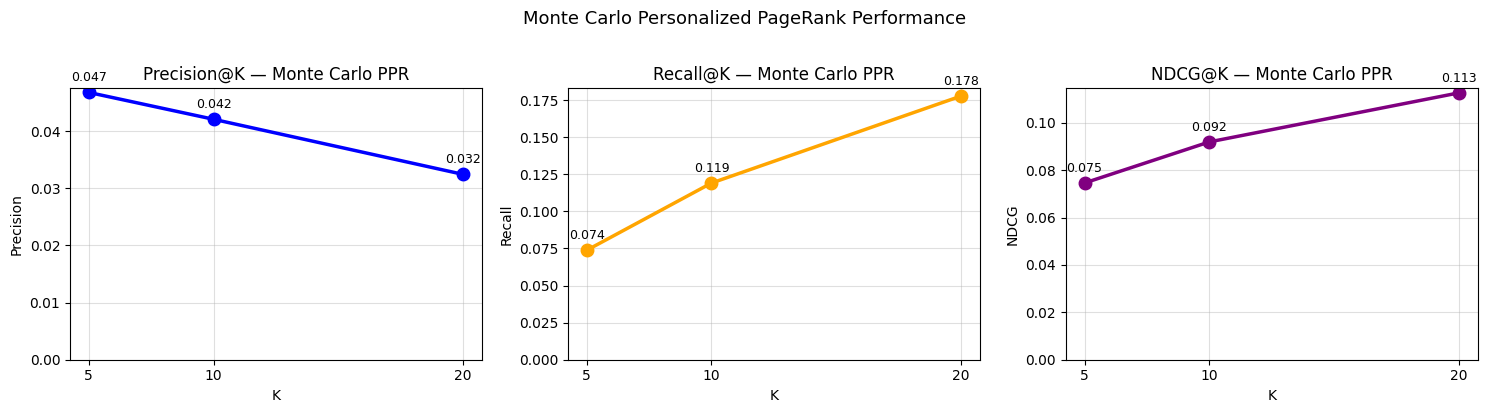

In [52]:
## ppr montecarlo

print("Setting up PPR Montecarlo")

adj = defaultdict(list)

for src, tgt in _train_edges:
    adj[int(src)].append(int(tgt))

n_papers = len(df_papers_f)

print(f"graph nodes: {n_papers:,}")

#----eval----
#params needed
ALPHA = 0.85
NUM_WALKS = 200        #num of random walks per query
WALK_LEN = 20          #steps per walk

#eval
query_papers = [src for src, tgts in test_gt.items() if len(tgts) >= 1]
np.random.shuffle(query_papers)

EVAL_SAMPLE = min(1000, len(query_papers))
query_papers = query_papers[:EVAL_SAMPLE]

print(f"\nevaluating on {EVAL_SAMPLE:,} query papers ...")

bucket = {
    k: {"p": [], "r": [], "ndcg": [], "hr": [], "mrr": []}
    for k in K_VALUES
}

#ppr w monte carlo
def monte_carlo_ppr(q_idx):
    visits = defaultdict(float)

    for _ in range(NUM_WALKS):

        node = q_idx

        for _ in range(WALK_LEN):
            visits[node] += 1

            if random.random() > ALPHA:
                node = q_idx
                continue

            neighbors = adj.get(node, [])

            if not neighbors:
                node = q_idx
            else:
                node = random.choice(neighbors)

    #normalize scores
    total = sum(visits.values())
    if total == 0:
        return np.zeros(n_papers)

    scores = np.zeros(n_papers, dtype=np.float32)

    for node, count in visits.items():
        if node < n_papers:
            scores[node] = count / total

    return scores

t0 = time.monotonic()

LOG_EVERY = 25

for i, q_idx in enumerate(query_papers):
    scores = monte_carlo_ppr(q_idx)

    #exclude self
    scores[q_idx] = -np.inf

    #exclude training citations
    for excl in train_gt.get(q_idx, set()):
        if excl < len(scores):
            scores[excl] = -np.inf

    #top k recommendations
    recs = np.argsort(scores)[::-1][:K_MAX].tolist()

    rel = test_gt[q_idx]

    for k in K_VALUES:
        bucket[k]["p"].append(_precision_at_k(recs, rel, k))
        bucket[k]["r"].append(_recall_at_k(recs, rel, k))
        bucket[k]["ndcg"].append(_ndcg_at_k(recs, rel, k))
        bucket[k]["hr"].append(_hit_rate_at_k(recs, rel, k))
        bucket[k]["mrr"].append(_mrr(recs[:k], rel))

    if (i + 1) % LOG_EVERY == 0 or (i + 1) == EVAL_SAMPLE:

        elapsed = time.monotonic() - t0
        rate = (i + 1) / elapsed
        eta_s = (EVAL_SAMPLE - i - 1) / rate if rate > 0 else 0

        p10 = np.mean(bucket[10]["p"])
        hr10 = np.mean(bucket[10]["hr"])

        print(
            f"  [{i+1:>4}/{EVAL_SAMPLE}]  "
            f"{elapsed:5.1f}s elapsed  |  "
            f"ETA {eta_s:4.0f}s  |  "
            f"P@10={p10:.4f}  HR@10={hr10:.4f}"
        )
#---results---
#results
results_mc_ppr = {
    k: {
        "Precision": np.mean(bucket[k]["p"]),
        "Recall":    np.mean(bucket[k]["r"]),
        "NDCG":      np.mean(bucket[k]["ndcg"]),
        "Hit Rate":  np.mean(bucket[k]["hr"]),
        "MRR":       np.mean(bucket[k]["mrr"]),
    }
    for k in K_VALUES
}

print("\nMonte Carlo PPR Results")
print("=" * 50)

for metric in ["Precision", "Recall", "NDCG", "Hit Rate", "MRR"]:
    print(
        f"{metric:<12}",
        "".join(f"{results_mc_ppr[k][metric]:>10.4f}" for k in K_VALUES)
    )
#---graphs---
#graphs

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metric_colors = [
    ("Precision", "blue"),
    ("Recall", "orange"),
    ("NDCG", "purple")
]

for ax, (metric, color) in zip(axes, metric_colors):

    vals = [results_mc_ppr[k][metric] for k in K_VALUES]

    ax.plot(
        K_VALUES,
        vals,
        marker="o",
        linewidth=2.5,
        color=color,
        markersize=9
    )

    for k, v in zip(K_VALUES, vals):
        ax.annotate(
            f"{v:.3f}",
            (k, v),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9
        )

    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K — Monte Carlo PPR")
    ax.set_xticks(K_VALUES)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.4)

plt.suptitle("Monte Carlo Personalized PageRank Performance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [85]:
compare_models()

no models registered yet - run evaluate_model() first


## Generalized Matrix Factorization (GMF)

GMF is a neural network-based approach for collaborative filtering. It learns embeddings for users and items and then combines them using an element-wise product, followed by a linear layer and a sigmoid activation to predict the likelihood of an interaction.

For implicit feedback (like citations), GMF aims to predict whether a user (citing paper) will interact with an item (cited paper). A common strategy for training implicit feedback models is to treat observed interactions as positive samples (rating = 1) and sample unobserved interactions as negative samples (rating = 0). Here, for simplicity, we'll start with observed interactions and later integrate negative sampling.

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import random
import time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

# ============================================================
# DEVICE SETUP
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

# ============================================================
# GMF MODEL
# ============================================================

class GMF(nn.Module):

    def __init__(
        self,
        num_users,
        num_items,
        embedding_dim
    ):

        super(GMF, self).__init__()

        self.user_embedding = nn.Embedding(
            num_users,
            embedding_dim
        )

        self.item_embedding = nn.Embedding(
            num_items,
            embedding_dim
        )

        self.fc = nn.Linear(
            embedding_dim,
            1
        )

    def forward(
        self,
        user_indices,
        item_indices
    ):

        user_embedded = self.user_embedding(
            user_indices
        )

        item_embedded = self.item_embedding(
            item_indices
        )

        element_product = (
            user_embedded * item_embedded
        )

        logits = self.fc(
            element_product
        ).squeeze()

        return logits

# ============================================================
# IMPLICIT DATASET
# ============================================================

class ImplicitDataset(Dataset):

    def __init__(
        self,
        interactions,
        num_items,
        num_negatives=4
    ):

        self.interactions = interactions

        self.num_items = num_items

        self.num_negatives = num_negatives

        self.user_pos_items = defaultdict(set)

        for u, i in interactions:

            self.user_pos_items[u].add(i)

    def __len__(self):

        return (
            len(self.interactions)
            * (1 + self.num_negatives)
        )

    def __getitem__(self, idx):

        interaction_idx = (
            idx // (1 + self.num_negatives)
        )

        offset = idx % (
            1 + self.num_negatives
        )

        user, pos_item = (
            self.interactions[interaction_idx]
        )

        # ----------------------------------------------------
        # POSITIVE SAMPLE
        # ----------------------------------------------------

        if offset == 0:

            return (
                torch.tensor(
                    user,
                    dtype=torch.long
                ),
                torch.tensor(
                    pos_item,
                    dtype=torch.long
                ),
                torch.tensor(
                    1.0,
                    dtype=torch.float32
                )
            )

        # ----------------------------------------------------
        # NEGATIVE SAMPLE
        # ----------------------------------------------------

        while True:

            neg_item = random.randint(
                0,
                self.num_items - 1
            )

            if (
                neg_item
                not in self.user_pos_items[user]
            ):
                break

        return (
            torch.tensor(
                user,
                dtype=torch.long
            ),
            torch.tensor(
                neg_item,
                dtype=torch.long
            ),
            torch.tensor(
                0.0,
                dtype=torch.float32
            )
        )

# ============================================================
# TRAINING SETUP
# ============================================================

num_users = (
    df_papers_f['paper_idx'].max() + 1
)

num_items = num_users

embedding_dim = 32

num_negatives = 4

epochs = 5

batch_size = 512

learning_rate = 0.001

# ============================================================
# TRAIN INTERACTIONS
# ============================================================

train_interactions = [

    (int(u), int(i))

    for u, i in _train_edges
]

# ============================================================
# DATASET + DATALOADER
# ============================================================

gmf_dataset = ImplicitDataset(

    interactions=train_interactions,

    num_items=num_items,

    num_negatives=num_negatives
)

gmf_dataloader = DataLoader(

    gmf_dataset,

    batch_size=batch_size,

    shuffle=True,

    num_workers=0,

    pin_memory=True
)

# ============================================================
# MODEL
# ============================================================

gmf_model = GMF(

    num_users=num_users,

    num_items=num_items,

    embedding_dim=embedding_dim

).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(

    gmf_model.parameters(),

    lr=learning_rate
)

# ============================================================
# TRAINING LOOP
# ============================================================

print(
    f"\nTraining GMF for {epochs} epochs..."
)

train_start = time.monotonic()

for epoch in range(epochs):

    gmf_model.train()

    total_loss = 0

    epoch_start = time.monotonic()

    for (
        user_indices,
        item_indices,
        labels
    ) in gmf_dataloader:

        user_indices = (
            user_indices.to(device)
        )

        item_indices = (
            item_indices.to(device)
        )

        labels = labels.to(device)

        optimizer.zero_grad()

        logits = gmf_model(

            user_indices,

            item_indices
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    epoch_time = (
        time.monotonic() - epoch_start
    )

    avg_loss = (
        total_loss / len(gmf_dataloader)
    )

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss={avg_loss:.4f} | "
        f"Time={epoch_time:.1f}s"
    )

train_elapsed = (
    time.monotonic() - train_start
)

print(
    f"\nTraining completed in "
    f"{train_elapsed:.1f}s"
)

# ============================================================
# EVALUATION
# ============================================================

gmf_model.eval()

query_papers_gmf = [

    src

    for src, tgts in test_gt.items()

    if len(tgts) >= 1
]

np.random.shuffle(query_papers_gmf)

# ------------------------------------------------------------
# IMPORTANT:
# Reduce evaluation set for speed
# ------------------------------------------------------------

EVAL_SAMPLE_GMF = min(

    200,

    len(query_papers_gmf)
)

query_papers_gmf = (

    query_papers_gmf[:EVAL_SAMPLE_GMF]
)

print(
    f"\nEvaluating on "
    f"{EVAL_SAMPLE_GMF:,} queries..."
)

# ============================================================
# METRIC BUCKETS
# ============================================================

bucket_gmf = {

    k: {

        "p": [],

        "r": [],

        "ndcg": [],

        "hr": [],

        "mrr": []
    }

    for k in K_VALUES
}

# ============================================================
# CACHE ITEM EMBEDDINGS
# ============================================================

with torch.no_grad():

    all_items_tensor = torch.arange(

        num_items,

        dtype=torch.long,

        device=device
    )

    all_items_embedded = (

        gmf_model.item_embedding(
            all_items_tensor
        )
    )

# ============================================================
# EVALUATION LOOP
# ============================================================

LOG_EVERY_GMF = 25

eval_start = time.monotonic()

with torch.no_grad():

    for i, q_idx in enumerate(query_papers_gmf):

        # ----------------------------------------------------
        # USER EMBEDDING
        # ----------------------------------------------------

        user_tensor = torch.tensor(

            [q_idx],

            dtype=torch.long,

            device=device
        )

        user_embedded = (

            gmf_model.user_embedding(
                user_tensor
            )
        )

        # ----------------------------------------------------
        # VECTORIZE ALL ITEM SCORES
        # ----------------------------------------------------

        element_product = (

            user_embedded
            * all_items_embedded
        )

        logits = gmf_model.fc(
            element_product
        ).squeeze()

        scores = torch.sigmoid(logits)

        # ----------------------------------------------------
        # EXCLUDE SELF
        # ----------------------------------------------------

        scores[q_idx] = -1e9

        # ----------------------------------------------------
        # EXCLUDE TRAIN INTERACTIONS
        # ----------------------------------------------------

        exclude_items = list(

            train_gt.get(q_idx, set())
        )

        if len(exclude_items) > 0:

            exclude_tensor = torch.tensor(

                exclude_items,

                dtype=torch.long,

                device=device
            )

            scores[exclude_tensor] = -1e9

        # ----------------------------------------------------
        # FAST GPU TOP-K
        # ----------------------------------------------------

        _, top_indices = torch.topk(

            scores,

            K_MAX
        )

        recs = top_indices.cpu().tolist()

        # ----------------------------------------------------
        # GROUND TRUTH
        # ----------------------------------------------------

        rel = test_gt[q_idx]

        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        for k in K_VALUES:

            bucket_gmf[k]["p"].append(

                _precision_at_k(
                    recs,
                    rel,
                    k
                )
            )

            bucket_gmf[k]["r"].append(

                _recall_at_k(
                    recs,
                    rel,
                    k
                )
            )

            bucket_gmf[k]["ndcg"].append(

                _ndcg_at_k(
                    recs,
                    rel,
                    k
                )
            )

            bucket_gmf[k]["hr"].append(

                _hit_rate_at_k(
                    recs,
                    rel,
                    k
                )
            )

            bucket_gmf[k]["mrr"].append(

                _mrr(
                    recs[:k],
                    rel
                )
            )

        # ----------------------------------------------------
        # LOGGING
        # ----------------------------------------------------

        if (
            (i + 1) % LOG_EVERY_GMF == 0
            or
            (i + 1) == EVAL_SAMPLE_GMF
        ):

            elapsed = (
                time.monotonic()
                - eval_start
            )

            rate = (
                (i + 1) / elapsed
            )

            eta = (
                (EVAL_SAMPLE_GMF - i - 1)
                / rate
            )

            p10 = np.mean(
                bucket_gmf[10]["p"]
            )

            hr10 = np.mean(
                bucket_gmf[10]["hr"]
            )

            print(
                f"[{i+1:>4}/"
                f"{EVAL_SAMPLE_GMF}]  "
                f"{elapsed:5.1f}s  |  "
                f"ETA {eta:4.0f}s  |  "
                f"P@10={p10:.4f}  "
                f"HR@10={hr10:.4f}"
            )

# ============================================================
# AGGREGATE RESULTS
# ============================================================

results_gmf = {

    k: {

        "Precision": np.mean(
            bucket_gmf[k]["p"]
        ),

        "Recall": np.mean(
            bucket_gmf[k]["r"]
        ),

        "NDCG": np.mean(
            bucket_gmf[k]["ndcg"]
        ),

        "Hit Rate": np.mean(
            bucket_gmf[k]["hr"]
        ),

        "MRR": np.mean(
            bucket_gmf[k]["mrr"]
        ),
    }

    for k in K_VALUES
}

total_eval_time = (

    time.monotonic() - eval_start
)

print(
    f"\nEvaluation completed in "
    f"{total_eval_time:.1f}s"
)

# ============================================================
# RESULTS TABLE
# ============================================================

print("\nGMF Evaluation Results")

print("=" * 60)

header = (

    f"{'Metric':<14}"

    +

    "".join(

        f"{'@'+str(k):>12}"

        for k in K_VALUES
    )
)

print(header)

print("-" * 60)

for metric in [

    "Precision",

    "Recall",

    "NDCG",

    "Hit Rate",

    "MRR"
]:

    row = (

        f"{metric:<14}"

        +

        "".join(

            f"{results_gmf[k][metric]:>12.4f}"

            for k in K_VALUES
        )
    )

    print(row)

print("=" * 60)

# ============================================================
# PLOTS
# ============================================================

fig, axes = plt.subplots(

    1,

    3,

    figsize=(15, 4)
)

metric_colors = [

    ("Precision", "blue"),

    ("Recall", "orange"),

    ("NDCG", "purple")
]

for ax, (metric, color) in zip(

    axes,

    metric_colors
):

    vals = [

        results_gmf[k][metric]

        for k in K_VALUES
    ]

    ax.plot(

        K_VALUES,

        vals,

        marker="o",

        linewidth=2.5,

        markersize=8,

        color=color
    )

    for k, v in zip(

        K_VALUES,

        vals
    ):

        ax.annotate(

            f"{v:.3f}",

            (k, v),

            textcoords="offset points",

            xytext=(0, 8),

            ha="center",

            fontsize=9
        )

    ax.set_xlabel("K")

    ax.set_ylabel(metric)

    ax.set_title(
        f"{metric}@K — GMF"
    )

    ax.set_xticks(K_VALUES)

    ax.grid(alpha=0.4)

plt.suptitle(

    "Generalized Matrix Factorization (GMF) Performance",

    fontsize=13,

    y=1.02
)

plt.tight_layout()

plt.show()

## Bandits Model: Epsilon-Greedy

A multi-armed bandit is a classic problem that exemplifies the exploration-exploitation trade-off. In the context of recommendation systems, 'arms' can represent different items (e.g., papers) or strategies for recommending items. The goal is to maximize the total reward (e.g., user engagement, citation likelihood) over a series of trials.

The Epsilon-Greedy strategy is a simple yet effective approach:

1.  **Exploration (with probability epsilon `ε`)**: Randomly choose an arm to try. This allows the agent to discover potentially better arms.
2.  **Exploitation (with probability `1 - ε`)**: Choose the arm that currently has the highest estimated average reward. This leverages the knowledge gained so far.

Over time, as `ε` typically decays, the model shifts from exploring new options to exploiting the best-known options.

PREPARING PAPER TEXT
Total papers: 163,275

Building TF-IDF matrix...
TF-IDF matrix built.

DEMONSTRATION

Query paper: 77534
True citations: [35425, 36923, 4908, 71933]

Retrieved candidates: 200

Simulating interactions:

STEP  1 | Recommended=71933 | Reward=1 | Q=1.000
STEP  2 | Recommended=71933 | Reward=1 | Q=1.000
STEP  6 | Recommended=71933 | Reward=1 | Q=1.000
STEP  7 | Recommended=71933 | Reward=1 | Q=1.000
STEP  8 | Recommended=71933 | Reward=1 | Q=1.000
STEP  9 | Recommended=71933 | Reward=1 | Q=1.000
STEP 10 | Recommended=71933 | Reward=1 | Q=1.000
STEP 11 | Recommended=71933 | Reward=1 | Q=1.000
STEP 12 | Recommended=71933 | Reward=1 | Q=1.000
STEP 13 | Recommended=71933 | Reward=1 | Q=1.000
STEP 14 | Recommended=71933 | Reward=1 | Q=1.000
STEP 15 | Recommended=71933 | Reward=1 | Q=1.000
STEP 16 | Recommended=71933 | Reward=1 | Q=1.000
STEP 18 | Recommended=71933 | Reward=1 | Q=1.000
STEP 19 | Recommended=71933 | Reward=1 | Q=1.000
STEP 20 | Recommended=71933 | Reward=1 | 

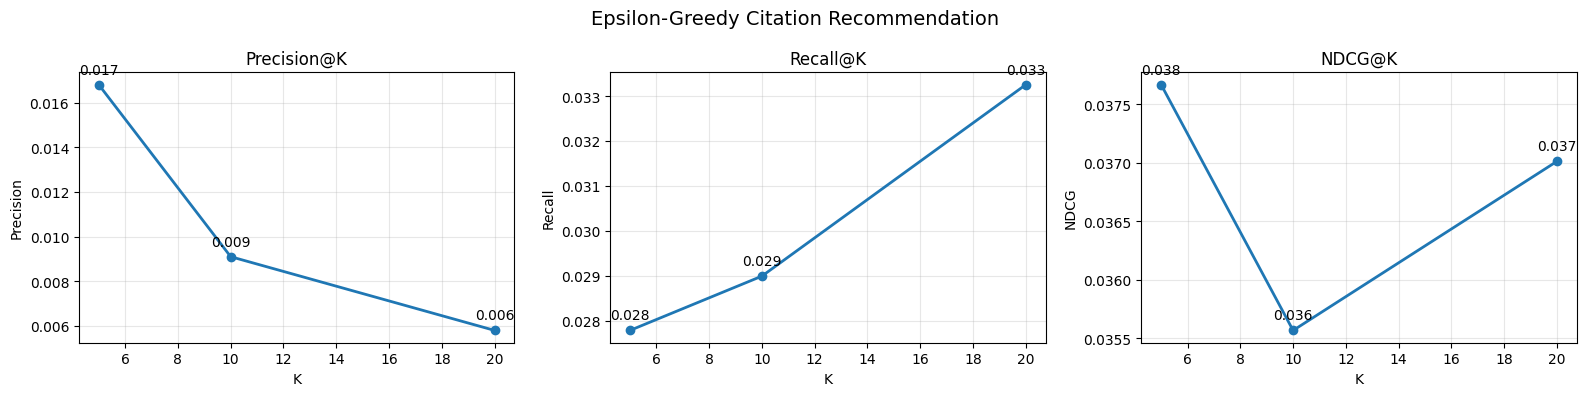

In [53]:
# ============================================================
# EPSILON-GREEDY CITATION RECOMMENDER

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# CONFIG
# ============================================================

EPSILON = 0.10
CANDIDATE_POOL_SIZE = 200
EVAL_SAMPLE = 1000

# Example:
# K_VALUES = [5, 10, 20]
# K_MAX = max(K_VALUES)

# ============================================================
# PREPARE TEXT
# ============================================================

print("=" * 60)
print("PREPARING PAPER TEXT")
print("=" * 60)

# ------------------------------------------------------------
# ADAPT COLUMN NAMES IF NEEDED
# ------------------------------------------------------------

TITLE_COL = "title"
ABSTRACT_COL = "abstract"

# fill NaNs
df_papers_f[TITLE_COL] = df_papers_f[TITLE_COL].fillna("")
df_papers_f[ABSTRACT_COL] = df_papers_f[ABSTRACT_COL].fillna("")

# combine title + abstract
paper_texts = (
    df_papers_f[TITLE_COL] + " " +
    df_papers_f[ABSTRACT_COL]
).tolist()

paper_indices = df_papers_f["paper_idx"].tolist()

num_items = len(paper_indices)

print(f"Total papers: {num_items:,}")

# ============================================================
# TF-IDF RETRIEVER
# ============================================================

print("\nBuilding TF-IDF matrix...")

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=50000
)

tfidf_matrix = vectorizer.fit_transform(paper_texts)

print("TF-IDF matrix built.")

# ============================================================
# RETRIEVAL FUNCTION
# ============================================================

def retrieve_candidates_tfidf(
    query_paper_idx,
    top_k=200
):
    """
    Retrieve top-K similar papers using TF-IDF cosine similarity.
    """

    query_vector = tfidf_matrix[query_paper_idx]

    sims = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()

    # exclude self
    sims[query_paper_idx] = -1

    # retrieve top-k
    candidate_indices = np.argpartition(
        sims,
        -top_k
    )[-top_k:]

    # sort by similarity
    candidate_indices = candidate_indices[
        np.argsort(sims[candidate_indices])[::-1]
    ]

    return candidate_indices.tolist()

# ============================================================
# EPSILON-GREEDY RERANKER
# ============================================================

class EpsilonGreedy:

    def __init__(
        self,
        candidate_items,
        epsilon=0.1
    ):

        self.items = np.array(candidate_items)

        self.n_items = len(candidate_items)

        self.epsilon = epsilon

        self.counts = np.zeros(self.n_items)

        self.values = np.zeros(self.n_items)

    # --------------------------------------------------------

    def recommend(self):

        # exploration
        if np.random.rand() < self.epsilon:

            unexplored = np.where(self.counts == 0)[0]

            if len(unexplored) > 0:
                idx = np.random.choice(unexplored)
            else:
                idx = np.random.randint(self.n_items)

        # exploitation
        else:

            idx = np.argmax(self.values)

        return self.items[idx]

    # --------------------------------------------------------

    def update(self, item_id, reward):

        idx = np.where(self.items == item_id)[0][0]

        self.counts[idx] += 1

        n = self.counts[idx]

        value = self.values[idx]

        # incremental average
        self.values[idx] = value + (reward - value) / n

    # --------------------------------------------------------

    def rank_items(self):

        ranked_idx = np.argsort(self.values)[::-1]

        return self.items[ranked_idx].tolist()

# ============================================================
# METRICS
# ============================================================

def precision_at_k(recs, rel, k):

    recs_k = recs[:k]

    hits = len(set(recs_k) & set(rel))

    return hits / k

# ------------------------------------------------------------

def recall_at_k(recs, rel, k):

    recs_k = recs[:k]

    hits = len(set(recs_k) & set(rel))

    return hits / len(rel) if len(rel) > 0 else 0

# ------------------------------------------------------------

def dcg_at_k(recs, rel, k):

    score = 0.0

    for i, r in enumerate(recs[:k]):

        if r in rel:
            score += 1 / np.log2(i + 2)

    return score

# ------------------------------------------------------------

def ndcg_at_k(recs, rel, k):

    ideal = dcg_at_k(list(rel), rel, min(k, len(rel)))

    if ideal == 0:
        return 0

    return dcg_at_k(recs, rel, k) / ideal

# ------------------------------------------------------------

def hit_rate_at_k(recs, rel, k):

    return int(len(set(recs[:k]) & set(rel)) > 0)

# ------------------------------------------------------------

def mrr(recs, rel):

    for i, r in enumerate(recs):

        if r in rel:
            return 1 / (i + 1)

    return 0

# ============================================================
# DEMONSTRATION
# ============================================================

print("\n" + "=" * 60)
print("DEMONSTRATION")
print("=" * 60)

demo_query = list(test_gt.keys())[0]

demo_truth = test_gt[demo_query]

print(f"\nQuery paper: {demo_query}")
print(f"True citations: {list(demo_truth)}")

# ------------------------------------------------------------
# RETRIEVE CANDIDATES
# ------------------------------------------------------------

candidate_pool = retrieve_candidates_tfidf(
    demo_query,
    top_k=CANDIDATE_POOL_SIZE
)

print(f"\nRetrieved candidates: {len(candidate_pool)}")

# ============================================================
# BANDIT
# ============================================================

bandit = EpsilonGreedy(
    candidate_pool,
    epsilon=EPSILON
)

# ------------------------------------------------------------
# ONLINE LEARNING SIMULATION
# ------------------------------------------------------------

NUM_INTERACTIONS = 50

print("\nSimulating interactions:\n")

for step in range(NUM_INTERACTIONS):

    rec = bandit.recommend()

    reward = int(rec in demo_truth)

    bandit.update(rec, reward)

    if reward == 1:

        idx = np.where(
            bandit.items == rec
        )[0][0]

        print(
            f"STEP {step+1:2d} | "
            f"Recommended={rec} | "
            f"Reward={reward} | "
            f"Q={bandit.values[idx]:.3f}"
        )

# ------------------------------------------------------------
# FINAL RANKING
# ------------------------------------------------------------

final_recs = bandit.rank_items()[:20]

hits = set(final_recs) & set(demo_truth)

print("\nTop Recommendations:")
print(final_recs)

print("\nHits:")
print(hits)

# ============================================================
# OFFLINE EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("OFFLINE EVALUATION")
print("=" * 60)

query_papers = [
    q for q in test_gt
    if len(test_gt[q]) > 0
]

np.random.shuffle(query_papers)

query_papers = query_papers[:min(
    EVAL_SAMPLE,
    len(query_papers)
)]

print(f"\nEvaluating on {len(query_papers):,} papers")

# ============================================================
# RESULTS STORAGE
# ============================================================

results = {
    k: {
        "Precision": [],
        "Recall": [],
        "NDCG": [],
        "HitRate": [],
        "MRR": []
    }
    for k in K_VALUES
}

# ============================================================
# EVAL LOOP
# ============================================================

t0 = time.monotonic()

for i, q in enumerate(query_papers):

    rel = test_gt[q]

    # --------------------------------------------------------
    # RETRIEVE CANDIDATES
    # --------------------------------------------------------

    candidates = retrieve_candidates_tfidf(
        q,
        top_k=CANDIDATE_POOL_SIZE
    )

    # --------------------------------------------------------
    # BANDIT
    # --------------------------------------------------------

    bandit = EpsilonGreedy(
        candidates,
        epsilon=EPSILON
    )

    # --------------------------------------------------------
    # SIMULATE INTERACTIONS
    #
    # IMPORTANT:
    # ONLY FOR ONLINE LEARNING SIMULATION
    #
    # This does NOT inject ground truth into candidates.
    # --------------------------------------------------------

    for _ in range(50):

        rec = bandit.recommend()

        reward = int(rec in rel)

        bandit.update(rec, reward)

    # --------------------------------------------------------
    # FINAL RANKING
    # --------------------------------------------------------

    ranked = bandit.rank_items()

    # remove training citations
    exclusions = train_gt.get(q, set())

    ranked = [
        r for r in ranked
        if r not in exclusions and r != q
    ]

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    for k in K_VALUES:

        results[k]["Precision"].append(
            precision_at_k(ranked, rel, k)
        )

        results[k]["Recall"].append(
            recall_at_k(ranked, rel, k)
        )

        results[k]["NDCG"].append(
            ndcg_at_k(ranked, rel, k)
        )

        results[k]["HitRate"].append(
            hit_rate_at_k(ranked, rel, k)
        )

        results[k]["MRR"].append(
            mrr(ranked[:k], rel)
        )

    # --------------------------------------------------------
    # LOGGING
    # --------------------------------------------------------

    if (i + 1) % 100 == 0:

        elapsed = time.monotonic() - t0

        print(
            f"[{i+1:4d}/{len(query_papers)}] "
            f"{elapsed:.1f}s elapsed"
        )

# ============================================================
# FINAL RESULTS
# ============================================================

final_results = {
    k: {
        metric: np.mean(vals)
        for metric, vals in results[k].items()
    }
    for k in K_VALUES
}

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

header = (
    f"{'Metric':<14}" +
    "".join(f"{'@'+str(k):>12}" for k in K_VALUES)
)

print(header)

print("-" * 60)

for metric in [
    "Precision",
    "Recall",
    "NDCG",
    "HitRate",
    "MRR"
]:

    row = f"{metric:<14}"

    for k in K_VALUES:

        row += f"{final_results[k][metric]:>12.4f}"

    print(row)

print("=" * 60)

# ============================================================
# PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4)
)

plot_metrics = [
    "Precision",
    "Recall",
    "NDCG"
]

for ax, metric in zip(axes, plot_metrics):

    vals = [
        final_results[k][metric]
        for k in K_VALUES
    ]

    ax.plot(
        K_VALUES,
        vals,
        marker="o",
        linewidth=2
    )

    for k, v in zip(K_VALUES, vals):

        ax.annotate(
            f"{v:.3f}",
            (k, v),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center"
        )

    ax.set_title(f"{metric}@K")

    ax.set_xlabel("K")

    ax.set_ylabel(metric)

    ax.grid(alpha=0.3)

plt.suptitle(
    "Epsilon-Greedy Citation Recommendation",
    fontsize=14
)

plt.tight_layout()

plt.show()

mean the model is only slightly better than random.They reflect:

sparse citation graphs

weak random retrieval

collaborative filtering limitations


**Neural Matrix Factorization (NeuMF)**


NeuMF combines the GMF and MLP architectures. The GMF part captures the linear interactions, while the MLP part captures non-linear interactions. Their outputs are then concatenated and fed into a final prediction layer.

In [66]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import time
import random

from collections import defaultdict

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# ============================================================
# DATA PREPARATION
# ============================================================

# REQUIRED:
#
# _train_edges
# df_papers_f
# train_gt
# test_gt
# EVAL_QUERY_PAPERS
#
# Example:
# _train_edges = [(u1, i1), (u2, i2), ...]

train_interactions = [
    (int(u), int(i))
    for u, i in _train_edges
]

num_users = int(df_papers_f["paper_idx"].max()) + 1
num_items = num_users

print("Users:", num_users)
print("Items:", num_items)

# ============================================================
# 1. OPTIMIZED NEUMF
# ============================================================

class NeuMF(nn.Module):

    def __init__(
        self,
        num_users,
        num_items,
        gmf_dim=16,
        mlp_dims=[32, 16],
    ):
        super().__init__()

        # -------------------------
        # GMF embeddings
        # -------------------------

        self.gmf_user_emb = nn.Embedding(
            num_users,
            gmf_dim,
        )

        self.gmf_item_emb = nn.Embedding(
            num_items,
            gmf_dim,
        )

        # -------------------------
        # MLP embeddings
        # -------------------------

        mlp_emb_dim = mlp_dims[0] // 2

        self.mlp_user_emb = nn.Embedding(
            num_users,
            mlp_emb_dim,
        )

        self.mlp_item_emb = nn.Embedding(
            num_items,
            mlp_emb_dim,
        )

        # -------------------------
        # MLP layers
        # -------------------------

        layers = []

        for i in range(len(mlp_dims) - 1):

            layers.append(
                nn.Linear(
                    mlp_dims[i],
                    mlp_dims[i + 1],
                )
            )

            layers.append(nn.ReLU())

        self.mlp_network = nn.Sequential(*layers)

        # -------------------------
        # Final layer
        # -------------------------

        self.fc_final = nn.Linear(
            gmf_dim + mlp_dims[-1],
            1,
        )

        self._init_weights()

    # ------------------------------------------------

    def _init_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Embedding):

                nn.init.normal_(
                    m.weight,
                    std=0.01,
                )

            elif isinstance(m, nn.Linear):

                nn.init.xavier_uniform_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    # ------------------------------------------------

    def forward(self, users, items):

        # -------------------------
        # GMF
        # -------------------------

        gmf_u = self.gmf_user_emb(users)

        gmf_i = self.gmf_item_emb(items)

        gmf_out = gmf_u * gmf_i

        # -------------------------
        # MLP
        # -------------------------

        mlp_u = self.mlp_user_emb(users)

        mlp_i = self.mlp_item_emb(items)

        mlp_in = torch.cat(
            [mlp_u, mlp_i],
            dim=-1,
        )

        mlp_out = self.mlp_network(mlp_in)

        # -------------------------
        # Fusion
        # -------------------------

        combined = torch.cat(
            [gmf_out, mlp_out],
            dim=-1,
        )

        logits = self.fc_final(combined)

        return logits.squeeze(-1)

# ============================================================
# 2. ULTRA FAST DATASET
# ============================================================

class UltraFastDataset(Dataset):

    def __init__(
        self,
        interactions,
        num_items,
        num_negatives=2,
    ):

        self.num_items = num_items

        self.users = np.array(
            [x[0] for x in interactions],
            dtype=np.int64,
        )

        self.pos_items = np.array(
            [x[1] for x in interactions],
            dtype=np.int64,
        )

        self.num_negatives = num_negatives

        # -------------------------
        # User positive interactions
        # -------------------------

        self.user_pos = defaultdict(set)

        for u, i in interactions:
            self.user_pos[u].add(i)

        # -------------------------
        # Pre-generate negatives
        # -------------------------

        total_pos = len(interactions)

        self.neg_items = np.random.randint(
            0,
            num_items,
            size=(total_pos, num_negatives),
            dtype=np.int64,
        )

        # Ensure negatives are not positives
        for idx in range(total_pos):

            u = self.users[idx]

            for j in range(num_negatives):

                neg = self.neg_items[idx, j]

                while neg in self.user_pos[u]:

                    neg = random.randint(
                        0,
                        num_items - 1,
                    )

                self.neg_items[idx, j] = neg

    # ------------------------------------------------

    def __len__(self):

        return len(self.users) * (
            1 + self.num_negatives
        )

    # ------------------------------------------------

    def __getitem__(self, idx):

        pos_idx = idx // (
            1 + self.num_negatives
        )

        offset = idx % (
            1 + self.num_negatives
        )

        u = self.users[pos_idx]

        # Positive
        if offset == 0:

            return (
                torch.tensor(u),
                torch.tensor(
                    self.pos_items[pos_idx]
                ),
                torch.tensor(
                    1.0,
                    dtype=torch.float32,
                ),
            )

        # Negative
        else:

            return (
                torch.tensor(u),
                torch.tensor(
                    self.neg_items[
                        pos_idx,
                        offset - 1,
                    ]
                ),
                torch.tensor(
                    0.0,
                    dtype=torch.float32,
                ),
            )

# ============================================================
# 3. TRAINING
# ============================================================

def train_optimized(
    model,
    train_interactions,
    num_items,
    epochs=3, # Reduced epochs for faster execution
    batch_size=4096,
):

    dataset = UltraFastDataset(
        train_interactions,
        num_items,
        num_negatives=2,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        persistent_workers=True,
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3,
    )

    criterion = nn.BCEWithLogitsLoss()

    scaler = torch.cuda.amp.GradScaler(
        enabled=torch.cuda.is_available()
    )

    model.to(device)

    # Optional PyTorch 2 acceleration
    try:
        model = torch.compile(model)
        print("Model compiled")
    except:
        pass

    # ------------------------------------------------

    for epoch in range(epochs):

        model.train()

        t0 = time.time()

        loss_log = []

        for users, items, labels in loader:

            users = users.to(
                device,
                non_blocking=True,
            )

            items = items.to(
                device,
                non_blocking=True,
            )

            labels = labels.to(
                device,
                non_blocking=True,
            )

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(
                enabled=torch.cuda.is_available()
            ):

                logits = model(
                    users,
                    items,
                )

                loss = criterion(
                    logits,
                    labels,
                )

            scaler.scale(loss).backward()

            scaler.step(optimizer)

            scaler.update()

            loss_log.append(loss.item())

        print(
            f"Epoch {epoch+1:02d} | "
            f"Loss: {np.mean(loss_log):.4f} | "
            f"Time: {time.time()-t0:.1f}s"
        )

# ============================================================
# 4. FAST EVALUATION
# ============================================================

@torch.no_grad()
def evaluate_fast(
    model,
    query_papers,
    train_gt,
    test_gt,
    k=10,
    eval_size=250, # Reduced eval_size for faster execution
):

    model.eval()

    hr_scores = []

    ndcg_scores = []

    # -------------------------
    # Faster evaluation
    # -------------------------

    query_papers = query_papers[:eval_size]

    print(
        f"Evaluating on "
        f"{len(query_papers)} queries..."
    )

    t0 = time.time()

    # -------------------------
    # Cache item embeddings
    # -------------------------

    item_gmf_emb = model.gmf_item_emb.weight

    item_mlp_emb = model.mlp_item_emb.weight

    # ------------------------------------------------

    for idx, q in enumerate(query_papers):

        u_tensor = torch.tensor(
            [q],
            device=device,
        )

        # -------------------------
        # GMF
        # -------------------------

        gmf_out = (
            model.gmf_user_emb(u_tensor)
            * item_gmf_emb
        )

        # -------------------------
        # MLP
        # -------------------------

        mlp_u = model.mlp_user_emb(
            u_tensor
        ).expand(
            num_items,
            -1,
        )

        mlp_input = torch.cat(
            [mlp_u, item_mlp_emb],
            dim=-1,
        )

        mlp_out = model.mlp_network(
            mlp_input
        )

        # -------------------------
        # Final scores
        # -------------------------

        scores = model.fc_final(
            torch.cat(
                [gmf_out, mlp_out],
                dim=-1,
            )
        ).squeeze(-1)

        # -------------------------
        # Remove seen items
        # -------------------------

        scores[q] = -1e9

        for excl in train_gt.get(q, set()):

            if excl < len(scores):
                scores[excl] = -1e9

        # -------------------------
        # Top-K
        # -------------------------

        _, topk = torch.topk(
            scores,
            k,
        )

        recs = topk.cpu().numpy()

        rel = test_gt.get(q, set())

        # -------------------------
        # HR
        # -------------------------

        hr_scores.append(
            float(
                len(set(recs) & rel) > 0
            )
        )

        # -------------------------
        # NDCG
        # -------------------------

        dcg = 0.0

        for rank, item in enumerate(recs):

            if item in rel:

                dcg += (
                    1.0 /
                    np.log2(rank + 2)
                )

        idcg = sum(
            1.0 / np.log2(i + 2)
            for i in range(
                min(k, len(rel))
            )
        )

        ndcg_scores.append(
            dcg / idcg
            if idcg > 0 else 0.0
        )

        if (idx + 1) % 100 == 0:

            print(
                f"{idx+1}/"
                f"{len(query_papers)} processed"
            )

    # ------------------------------------------------

    print(
        f"\nEvaluation Time: "
        f"{time.time()-t0:.1f}s"
    )

    print(
        f"HR@{k}: "
        f"{np.mean(hr_scores):.4f}"
    )

    print(
        f"NDCG@{k}: "
        f"{np.mean(ndcg_scores):.4f}"
    )

# ============================================================
# 5. CREATE MODEL
# ============================================================

model = NeuMF(
    num_users=num_users,
    num_items=num_items,
    gmf_dim=16,
    mlp_dims=[32, 16],
)

model = model.to(device)

# ============================================================
# 6. TRAIN
# ============================================================

train_optimized(
    model=model,
    train_interactions=train_interactions,
    num_items=num_items,
    epochs=3, # Reduced epochs for faster execution
    batch_size=4096,
)

# ============================================================
# 7. EVALUATE
# ============================================================

evaluate_fast(
    model=model,
    query_papers=EVAL_QUERY_PAPERS,
    train_gt=train_gt,
    test_gt=test_gt,
    k=K_VALUES[1], # Use K=10 for evaluation, or any K_VALUE
    eval_size=250, # Reduced eval_size for faster execution
)

# ============================================================
# 8. SAVE MODEL
# ============================================================

torch.save(
    model.state_dict(),
    "optimized_neumf.pt",
)

print("\nModel saved: optimized_neumf.pt")

Using device: cuda
Users: 163275
Items: 163275
Model compiled


/tmp/ipykernel_1879/486693248.py:337: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(
/tmp/ipykernel_1879/486693248.py:379: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Epoch 01 | Loss: 0.4545 | Time: 158.9s


/tmp/ipykernel_1879/486693248.py:379: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Epoch 02 | Loss: 0.3565 | Time: 154.6s
Epoch 03 | Loss: 0.2387 | Time: 155.5s
Evaluating on 250 queries...
100/250 processed
200/250 processed

Evaluation Time: 0.7s
HR@10: 0.2280
NDCG@10: 0.0493

Model saved: optimized_neumf.pt


Evaluating NeuMF model...

  evaluating : NeuMF
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]    0.2s  |  ETA    2s  |  P@10=0.0270  HR@10=0.1900
  [ 200/1000]    0.4s  |  ETA    2s  |  P@10=0.0280  HR@10=0.2250
  [ 300/1000]    0.6s  |  ETA    1s  |  P@10=0.0273  HR@10=0.2100
  [ 400/1000]    0.8s  |  ETA    1s  |  P@10=0.0288  HR@10=0.2250
  [ 500/1000]    1.0s  |  ETA    1s  |  P@10=0.0282  HR@10=0.2280
  [ 600/1000]    1.2s  |  ETA    1s  |  P@10=0.0275  HR@10=0.2183
  [ 700/1000]    1.4s  |  ETA    1s  |  P@10=0.0279  HR@10=0.2229
  [ 800/1000]    1.8s  |  ETA    0s  |  P@10=0.0292  HR@10=0.2313
  [ 900/1000]    2.2s  |  ETA    0s  |  P@10=0.0286  HR@10=0.2256
  [1000/1000]    2.6s  |  ETA    0s  |  P@10=0.0276  HR@10=0.2210

  done in 2.6s  (3 ms/paper)
  stored → MODEL_RESULTS['NeuMF']

Model Comparison  @K=10
Metric                            NeuMF  Hybrid TF-IDF + SVD                  SVD             PageRank      Monte Carlo PPR
--------------------------------------

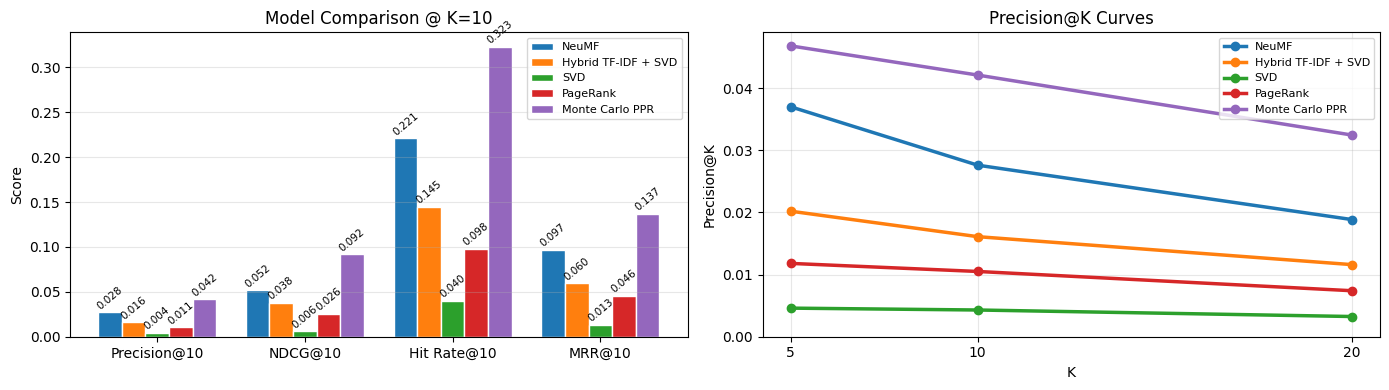

saved → model_comparison.png


In [88]:
import torch
import numpy as np
import time
from collections import defaultdict

# --- metric helpers ---

def _precision_at_k(recs: list, rel: set, k: int) -> float:
    return len(set(recs[:k]) & rel) / k

def _recall_at_k(recs: list, rel: set, k: int) -> float:
    return len(set(recs[:k]) & rel) / len(rel) if rel else 0.0

def _ndcg_at_k(recs: list, rel: set, k: int) -> float:
    dcg  = sum(1.0 / np.log2(i + 2) for i, r in enumerate(recs[:k]) if r in rel)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(k, len(rel))))
    return dcg / idcg if idcg > 0 else 0.0

def _hit_rate_at_k(recs: list, rel: set, k: int) -> float:
    return 1.0 if set(recs[:k]) & rel else 0.0

def _mrr(recs: list, rel: set) -> float:
    for i, r in enumerate(recs):
        if r in rel:
            return 1.0 / (i + 1)
    return 0.0


def evaluate_model(
    name: str,
    score_fn=None,
    batch_score_fn=None,
    batch_size: int = 100,
    k_values: list[int] | None = None,
    query_papers: list[int] | None = None,
) -> dict:
    """
    Evaluate any recommendation model against the shared held-out test set.

    Provide exactly one of:
        score_fn(query_idx: int) -> np.ndarray[n_papers]
            Per-paper scores. Use for models where batch scoring is awkward.
        batch_score_fn(indices: list[int]) -> np.ndarray[B, n_papers]
            Batch scores. Use for TF-IDF, matrix factorization, etc. - much faster.

    The framework handles self-exclusion, train-citation exclusion, top-K ranking
    via argpartition (O(n)), and progress logging automatically.

    Results are stored in MODEL_RESULTS[name] and returned as
    {k: {"Precision", "Recall", "NDCG", "Hit Rate", "MRR"}}.
    """
    if k_values is None:
        k_values = K_VALUES
    if query_papers is None:
        query_papers = EVAL_QUERY_PAPERS
    k_max  = max(k_values)
    n_eval = len(query_papers)
    ref_k  = 10 if 10 in k_values else k_values[-1]

    bucket = {k: {"p": [], "r": [], "ndcg": [], "hr": [], "mrr": []} for k in k_values}

    print(f"\n{'='*55}")
    print(f"  evaluating : {name}")
    print(f"  queries    : {n_eval:,}  |  K = {k_values}")
    print(f"{'='*55}")
    t0 = time.monotonic()

    def _rank(q_idx: int, scores: np.ndarray) -> list[int]:
        scores = scores.copy()
        scores[q_idx] = -np.inf
        for excl in train_gt.get(q_idx, set()):
            if excl < len(scores):
                scores[excl] = -np.inf
        top_part = np.argpartition(scores, -k_max)[-k_max:]
        return top_part[np.argsort(scores[top_part])[::-1]].tolist()

    def _accumulate(q_idx: int, recs: list[int]) -> None:
        rel = test_gt[q_idx]
        for k in k_values:
            bucket[k]["p"].append(_precision_at_k(recs, rel, k))
            bucket[k]["r"].append(_recall_at_k(recs, rel, k))
            bucket[k]["ndcg"].append(_ndcg_at_k(recs, rel, k))
            bucket[k]["hr"].append(_hit_rate_at_k(recs, rel, k))
            bucket[k]["mrr"].append(_mrr(recs[:k], rel))

    def _log(done: int) -> None:
        elapsed = time.monotonic() - t0
        rate    = done / elapsed if elapsed > 0 else 0
        eta     = (n_eval - done) / rate if rate > 0 else 0
        p   = np.mean(bucket[ref_k]["p"])  if bucket[ref_k]["p"]  else 0.0
        hr  = np.mean(bucket[ref_k]["hr"]) if bucket[ref_k]["hr"] else 0.0
        print(f"  [{done:>4}/{n_eval}]  {elapsed:5.1f}s  |  "
              f"ETA {eta:4.0f}s  |  P@{ref_k}={p:.4f}  HR@{ref_k}={hr:.4f}")

    if batch_score_fn is not None:
        for start in range(0, n_eval, batch_size):
            batch = query_papers[start : start + batch_size]
            batch_scores = batch_score_fn(batch)          # (B, n_papers)
            for j, q_idx in enumerate(batch):
                _accumulate(q_idx, _rank(q_idx, batch_scores[j]))
            _log(min(start + batch_size, n_eval))
    else:
        for i, q_idx in enumerate(query_papers):
            _accumulate(q_idx, _rank(q_idx, score_fn(q_idx)))
            if (i + 1) % 100 == 0 or (i + 1) == n_eval:
                _log(i + 1)

    elapsed = time.monotonic() - t0
    result = {
        k: {
            "Precision": np.mean(bucket[k]["p"]),
            "Recall":    np.mean(bucket[k]["r"]),
            "NDCG":      np.mean(bucket[k]["ndcg"]),
            "Hit Rate":  np.mean(bucket[k]["hr"]),
            "MRR":       np.mean(bucket[k]["mrr"]),
        }
        for k in k_values
    }
    MODEL_RESULTS[name] = result
    print(f"\n  done in {elapsed:.1f}s  ({1000*elapsed/n_eval:.0f} ms/paper)")
    print(f"  stored → MODEL_RESULTS['{name}']")
    return result


# --- NeuMF specific batch scoring function ---
@torch.no_grad()
def _neumf_batch_score(indices: list[int]) -> np.ndarray:
    model.eval() # Ensure model is in evaluation mode

    # Convert query indices to tensor
    query_users_tensor = torch.tensor(indices, dtype=torch.long, device=device)

    # Cache item embeddings once for all items
    # These are weights directly from the embedding layers
    all_item_gmf_emb = model.gmf_item_emb.weight # (num_items, gmf_dim)
    all_item_mlp_emb = model.mlp_item_emb.weight # (num_items, mlp_emb_dim)

    # num_items is a global variable from the GMF/NeuMF setup cell (hwastYOdg8y8)
    # It should be 163275
    # However, to be safe and self-contained, let's get it from the model
    _num_items = model.gmf_item_emb.weight.shape[0]

    batch_size = len(indices)

    # --- GMF part ---
    user_gmf_emb_batch = model.gmf_user_emb(query_users_tensor) # (batch_size, gmf_dim)
    # Expand user embeddings to match the shape needed for element-wise product with all items
    user_gmf_emb_expanded = user_gmf_emb_batch.unsqueeze(1).expand(-1, _num_items, -1) # (batch_size, num_items, gmf_dim)
    # Perform element-wise product. item_gmf_emb is unsqueezed to (1, num_items, gmf_dim) for broadcasting
    gmf_product_scores = user_gmf_emb_expanded * all_item_gmf_emb.unsqueeze(0) # (batch_size, num_items, gmf_dim)

    # --- MLP part ---
    user_mlp_emb_batch = model.mlp_user_emb(query_users_tensor) # (batch_size, mlp_emb_dim)
    # Expand user embeddings
    user_mlp_emb_expanded = user_mlp_emb_batch.unsqueeze(1).expand(-1, _num_items, -1) # (batch_size, num_items, mlp_emb_dim)
    # Concatenate user and item MLP embeddings
    mlp_input = torch.cat([user_mlp_emb_expanded, all_item_mlp_emb.unsqueeze(0).expand(batch_size, -1, -1)], dim=-1) # (batch_size, num_items, mlp_input_dim)
    mlp_output = model.mlp_network(mlp_input) # (batch_size, num_items, mlp_output_dim)

    # --- Fusion and Final Layer ---
    # Concatenate GMF and MLP outputs
    combined_features = torch.cat([gmf_product_scores, mlp_output], dim=-1) # (batch_size, num_items, final_fc_input_dim)
    # Pass through the final linear layer
    logits = model.fc_final(combined_features).squeeze(-1) # (batch_size, num_items)

    # Apply sigmoid to get probability-like scores
    scores = torch.sigmoid(logits)

    return scores.cpu().numpy()


print("Evaluating NeuMF model...")
neumf_results = evaluate_model(
    "NeuMF",
    batch_score_fn=_neumf_batch_score,
    batch_size=100,
)

# Manually add SVD, PageRank, and Monte Carlo PPR results to MODEL_RESULTS
MODEL_RESULTS["SVD"] = results_svd
MODEL_RESULTS["PageRank"] = results_pr
MODEL_RESULTS["Monte Carlo PPR"] = results_mc_ppr

compare_models()

**Hybrid Model TF-IDF + SVD**

This model combines two approaches to recommendation: content-based filtering (TF-IDF) and collaborative filtering (SVD). The goal is to leverage both the textual content of papers and the implicit relationships derived from citation patterns.

-   **TF-IDF for Content Similarity**: Each paper's title and abstract are vectorized using TF-IDF to capture its textual content. This provides a content-based representation of each paper.
-   **Truncated SVD for Latent Factors**: The TF-IDF matrix is then reduced in dimensionality using Truncated SVD. This process extracts latent factors (embeddings) that represent the underlying themes or characteristics of papers, effectively capturing indirect relationships and reducing noise.

When recommending, the model calculates the cosine similarity between the query paper's SVD embedding and all other paper embeddings. This allows for recommendations based on both direct textual similarity (via TF-IDF) and the learned latent semantic relationships (via SVD).

In [78]:
# ============================================================
# HYBRID RESEARCH PAPER RECOMMENDER
# TF-IDF + SVD (MEMORY OPTIMIZED)
# ============================================================

import gc
import numpy as np
import pandas as pd

from scipy.sparse import save_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import linear_kernel


# ============================================================
# LOAD DATASET
# ============================================================

# Expected columns:
# paper_id, title, abstract

papers_path = OUTPUT_DIR / "papers.csv"

cols = ["arxiv_id", "title", "abstract"]

papers = pd.read_csv(
    papers_path,
    usecols=cols
)

papers = papers.fillna("")

print("Total papers:", len(papers))


# ============================================================
# CREATE COMBINED TEXT
# ============================================================

papers["text"] = (
    papers["title"].astype(str) + " " +
    papers["abstract"].astype(str)
)

papers["text"] = papers["text"].str.replace(
    "\n",
    " ",
    regex=True
)


# ============================================================
# TF-IDF VECTORIZATION
# MEMORY OPTIMIZED
# ============================================================

MAX_FEATURES = 50000

vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    stop_words="english",
    min_df=3,
    max_df=0.90,
    ngram_range=(1, 2),
    dtype=np.float32
)

print("Building TF-IDF matrix...")

tfidf_matrix = vectorizer.fit_transform(
    papers["text"]
)

print("TF-IDF Shape:", tfidf_matrix.shape)
print("Non-zero values:", tfidf_matrix.nnz)


# ============================================================
# OPTIONAL: SAVE TF-IDF MATRIX
# ============================================================

save_npz(
    "tfidf_matrix.npz",
    tfidf_matrix
)

print("TF-IDF matrix saved.")


# ============================================================
# APPLY SVD
# REDUCE DIMENSIONS
# ============================================================

N_COMPONENTS = 128

print("Running Truncated SVD...")

svd = TruncatedSVD(
    n_components=N_COMPONENTS,
    random_state=42
)

paper_embeddings = svd.fit_transform(
    tfidf_matrix
)

paper_embeddings = paper_embeddings.astype(
    np.float32
)

print("Embeddings Shape:", paper_embeddings.shape)


# ============================================================
# NORMALIZE EMBEDDINGS
# ============================================================

paper_embeddings = normalize(
    paper_embeddings
)

print("Normalization complete.")


# ============================================================
# FREE MEMORY
# IMPORTANT
# ============================================================

del tfidf_matrix

gc.collect()

print("Sparse TF-IDF matrix deleted from memory.")


# ============================================================
# CREATE LOOKUP TABLES
# ============================================================

paperid_to_idx = {
    pid: idx
    for idx, pid in enumerate(papers["arxiv_id"])
}

idx_to_paperid = {
    idx: pid
    for idx, pid in enumerate(papers["arxiv_id"])
}

print("Lookup dictionaries created.")


# ============================================================
# RECOMMENDATION FUNCTION
# ============================================================

def recommend_papers(
    paper_id,
    top_k=10
):

    if paper_id not in paperid_to_idx:
        print("Paper ID not found.")
        return None

    idx = paperid_to_idx[paper_id]

    query_vec = paper_embeddings[idx:idx+1]

    # cosine similarity
    scores = linear_kernel(
        query_vec,
        paper_embeddings
    ).flatten()

    # remove self similarity
    scores[idx] = -1

    # fast top-k retrieval
    top_indices = np.argpartition(
        scores,
        -top_k
    )[-top_k:]

    # sort only top-k
    top_indices = top_indices[
        np.argsort(scores[top_indices])[::-1]
    ]

    results = papers.iloc[top_indices][[
        "arxiv_id",
        "title"
    ]].copy()

    results["score"] = scores[top_indices]

    return results.reset_index(drop=True)


# ============================================================
# EXAMPLE USAGE
# ============================================================

sample_paper = papers.iloc[0]["arxiv_id"]

recommendations = recommend_papers(
    sample_paper,
    top_k=10
)

print(recommendations)


# ============================================================
# SAVE EMBEDDINGS
# ============================================================

np.save(
    "paper_embeddings.npy",
    paper_embeddings
)

print("Embeddings saved.")


# ============================================================
# LOAD EMBEDDINGS WITHOUT FULL RAM USAGE
# ============================================================

paper_embeddings = np.load(
    "paper_embeddings.npy",
    mmap_mode="r"
)

print("Embeddings loaded with memory mapping.")


# ============================================================
# OPTIONAL BATCH RECOMMENDATIONS
# ============================================================

def recommend_batch(
    indices,
    top_k=10
):

    sims = linear_kernel(
        paper_embeddings[indices],
        paper_embeddings
    )

    all_results = []

    for row_idx, sim_row in enumerate(sims):

        original_idx = indices[row_idx]

        sim_row[original_idx] = -1

        top_indices = np.argpartition(
            sim_row,
            -top_k
        )[-top_k:]

        top_indices = top_indices[
            np.argsort(
                sim_row[top_indices]
            )[::-1]
        ]

        all_results.append(top_indices)

    return all_results


# ============================================================
# OPTIONAL HYBRID SCORE
# ============================================================

def hybrid_score(
    content_score,
    citation_score,
    alpha=0.7
):

    return (
        alpha * content_score +
        (1 - alpha) * citation_score
    )


# ============================================================
# OPTIONAL EVALUATION
# ============================================================

def recall_at_k(
    recommended,
    ground_truth,
    k=10
):

    recommended = recommended[:k]

    hits = len(
        set(recommended) &
        set(ground_truth)
    )

    return hits / max(
        1,
        len(ground_truth)
    )


# ============================================================
# RECOMMENDED SETTINGS
# ============================================================

"""
8 GB RAM:
max_features = 30000
n_components = 64

12 GB RAM:
max_features = 50000
n_components = 128

16+ GB RAM:
max_features = 100000
n_components = 256
"""

Total papers: 163275
Building TF-IDF matrix...
TF-IDF Shape: (163275, 50000)
Non-zero values: 18801625
TF-IDF matrix saved.
Running Truncated SVD...
Embeddings Shape: (163275, 128)
Normalization complete.


Exception ignored in: <function ExactWeakKeyDictionary.__setitem__.<locals>.<lambda> at 0x7f9103576e80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/_dynamo/utils.py", line 1025, in <lambda>
    self.refs[idx] = weakref.ref(key, lambda ref: self._remove_id(idx))

KeyboardInterrupt: 


Sparse TF-IDF matrix deleted from memory.
Lookup dictionaries created.
     arxiv_id                                              title     score
0  1911.12487  Minimum Bayes Risk Training of RNN-Transducer ...  0.889830
1  1806.06342  Extending Recurrent Neural Aligner for Streami...  0.886876
2  1912.00863  Independent language modeling architecture for...  0.871262
3  2003.07962  Deliberation Model Based Two-Pass End-to-End S...  0.870998
4  2010.13878  Improved Neural Language Model Fusion for Stre...  0.864639
5  1912.03010  Semantic Mask for Transformer based End-to-End...  0.858754
6  2011.13148  Streaming end-to-end multi-talker speech recog...  0.854972
7  1902.07178  A spelling correction model for end-to-end spe...  0.854908
8  1909.12415  Improving RNN Transducer Modeling for End-to-E...  0.852529
9  1803.01090  On Modular Training of Neural Acoustics-to-Wor...  0.844259
Embeddings saved.
Embeddings loaded with memory mapping.


'\n8 GB RAM:\nmax_features = 30000\nn_components = 64\n\n12 GB RAM:\nmax_features = 50000\nn_components = 128\n\n16+ GB RAM:\nmax_features = 100000\nn_components = 256\n'


  evaluating : Hybrid TF-IDF + SVD
  queries    : 1,000  |  K = [5, 10, 20]
  [ 100/1000]    0.2s  |  ETA    2s  |  P@10=0.0190  HR@10=0.1700
  [ 200/1000]    0.4s  |  ETA    2s  |  P@10=0.0180  HR@10=0.1700
  [ 300/1000]    0.6s  |  ETA    1s  |  P@10=0.0173  HR@10=0.1567
  [ 400/1000]    0.8s  |  ETA    1s  |  P@10=0.0160  HR@10=0.1475
  [ 500/1000]    0.9s  |  ETA    1s  |  P@10=0.0154  HR@10=0.1380
  [ 600/1000]    1.1s  |  ETA    1s  |  P@10=0.0160  HR@10=0.1433
  [ 700/1000]    1.3s  |  ETA    1s  |  P@10=0.0161  HR@10=0.1443
  [ 800/1000]    1.5s  |  ETA    0s  |  P@10=0.0164  HR@10=0.1475
  [ 900/1000]    1.7s  |  ETA    0s  |  P@10=0.0162  HR@10=0.1456
  [1000/1000]    1.8s  |  ETA    0s  |  P@10=0.0161  HR@10=0.1450

  done in 1.8s  (2 ms/paper)
  stored → MODEL_RESULTS['Hybrid TF-IDF + SVD']

Model Comparison  @K=10
Metric                            NeuMF  Hybrid TF-IDF + SVD                  SVD             PageRank      Monte Carlo PPR               TF-IDF
---------------

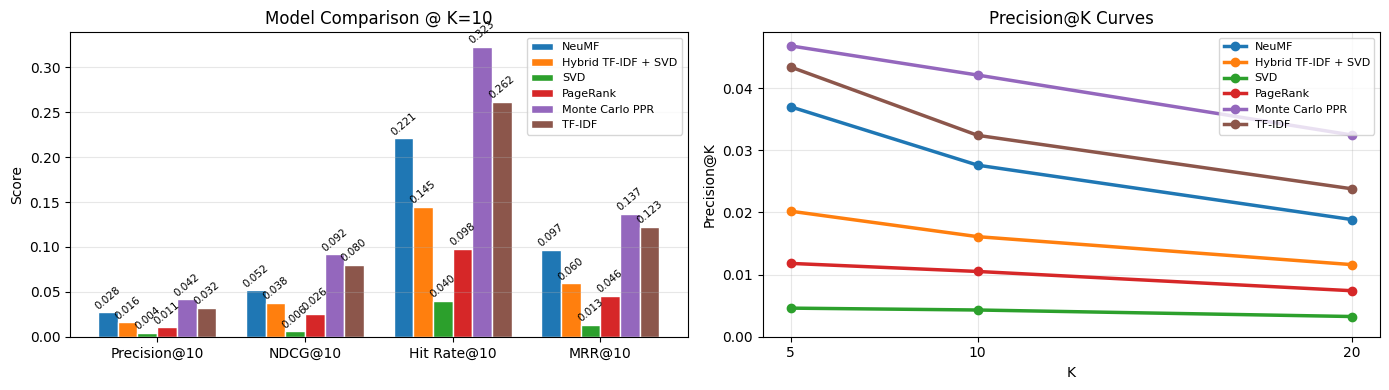

saved → model_comparison.png


In [91]:
def _hybrid_batch_score(indices: list[int]) -> np.ndarray:
    """Batch cosine similarities using pre-computed SVD embeddings."""
    global paper_embeddings
    # Ensure paper_embeddings is loaded with mmap_mode="r"
    if not isinstance(paper_embeddings, np.memmap):
        # The 'global' keyword is needed here to explicitly reference and potentially re-assign the global variable.
        paper_embeddings = np.load("paper_embeddings.npy", mmap_mode="r")

    # Calculate cosine similarity between query embeddings and all paper embeddings
    # Since embeddings are L2 normalized, dot product directly gives cosine similarity
    query_embeddings = paper_embeddings[indices]
    scores = linear_kernel(query_embeddings, paper_embeddings)
    return scores

hybrid_results = evaluate_model(
    "Hybrid TF-IDF + SVD",
    batch_score_fn=_hybrid_batch_score,
    batch_size=100,
)

compare_models()


Model Comparison  @K=10
Metric                            NeuMF  Hybrid TF-IDF + SVD                  SVD             PageRank      Monte Carlo PPR               TF-IDF
------------------------------------------------------------------------------------------------------------------------------------------------
Precision                        0.0276               0.0161               0.0043               0.0105               0.0421               0.0324
Recall                           0.0584               0.0511               0.0072               0.0313               0.1191               0.1026
NDCG                             0.0520               0.0378               0.0060               0.0257               0.0919               0.0800
Hit Rate                         0.2210               0.1450               0.0400               0.0980               0.3230               0.2620
MRR                              0.0970               0.0595               0.0133               0.0456   

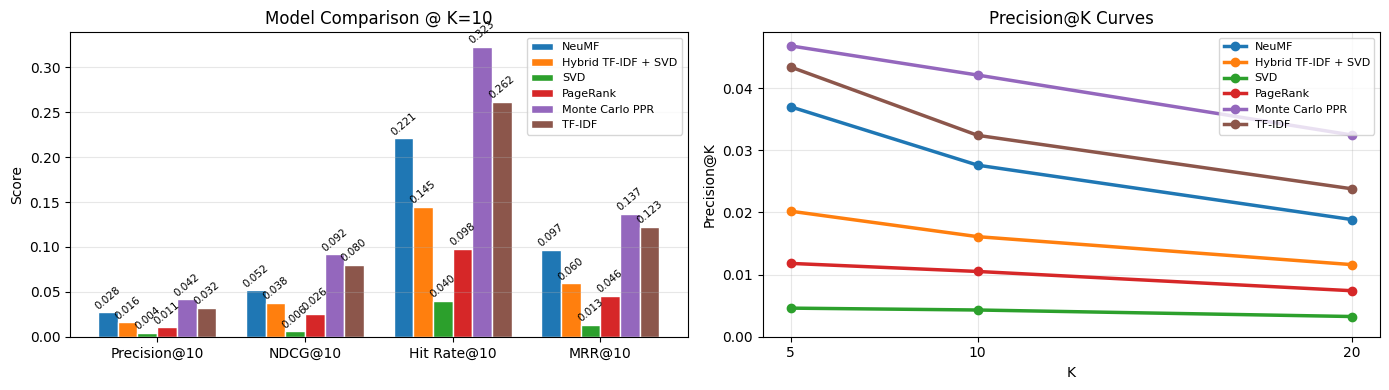

saved → model_comparison.png


In [90]:
# Consolidate all model results into the global MODEL_RESULTS dictionary
MODEL_RESULTS["TF-IDF"] = tfidf_results
MODEL_RESULTS["SVD"] = results_svd
MODEL_RESULTS["PageRank"] = results_pr
MODEL_RESULTS["Monte Carlo PPR"] = results_mc_ppr
MODEL_RESULTS["NeuMF"] = neumf_results
MODEL_RESULTS["Hybrid TF-IDF + SVD"] = hybrid_results

# Display the comparison of all models
compare_models()


Model Comparison  @K=10
Metric                            NeuMF  Hybrid TF-IDF + SVD                  SVD             PageRank      Monte Carlo PPR               TF-IDF
------------------------------------------------------------------------------------------------------------------------------------------------
Precision                        0.0276               0.0161               0.0043               0.0105               0.0421               0.0324
Recall                           0.0584               0.0511               0.0072               0.0313               0.1191               0.1026
NDCG                             0.0520               0.0378               0.0060               0.0257               0.0919               0.0800
Hit Rate                         0.2210               0.1450               0.0400               0.0980               0.3230               0.2620
MRR                              0.0970               0.0595               0.0133               0.0456   

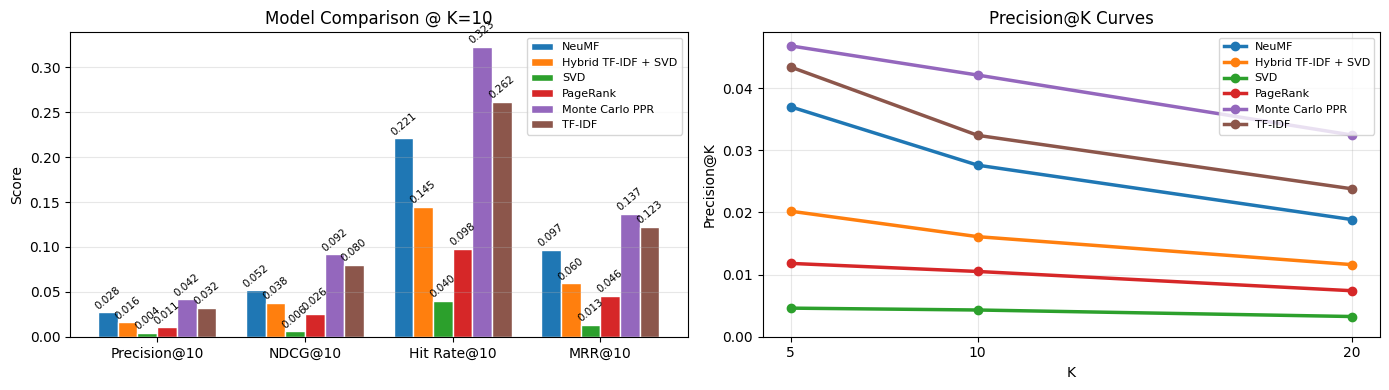

saved → model_comparison.png


In [89]:
# Consolidate all model results into the global MODEL_RESULTS dictionary
MODEL_RESULTS["TF-IDF"] = tfidf_results
MODEL_RESULTS["SVD"] = results_svd
MODEL_RESULTS["PageRank"] = results_pr
MODEL_RESULTS["Monte Carlo PPR"] = results_mc_ppr
MODEL_RESULTS["NeuMF"] = neumf_results
MODEL_RESULTS["Hybrid TF-IDF + SVD"] = hybrid_results

# Display the comparison of all models
compare_models()

---
## Section 9 - Export for Local Use

After all models are trained, download the files below from
`cmpe_256_project_files/` in Google Drive and put them in the
same folder as `app.py` on your local machine.

**Required (always):**

| File | Size (approx) | Purpose |
|---|---|---|
| `papers.csv` | ~60 MB | paper metadata (title, abstract, categories) |
| `citations.csv` | ~80 MB | citation edges |
| `tfidf_vectorizer.pkl` | ~10 MB | fitted TF-IDF vocabulary |
| `tfidf_matrix.npz` | ~250 MB | pre-built TF-IDF matrix (avoids ~60s rebuild) |

**Optional (add as teammates finish training):**

| File | Model |
|---|---|
| `svd_model.npz` | SVD collaborative filtering |
| `pagerank_scores.json` | PageRank |
| `hybrid_weights.json` | Hybrid |

Then run locally:

```bash
pip install gradio scikit-learn pandas numpy scipy
python app.py --data-dir /path/to/downloaded/files
# open http://127.0.0.1:7860
```


In [77]:
# Show all files in OUTPUT_DIR and their sizes so you know exactly what to download.
print(f"Files in {OUTPUT_DIR}:")
print()
total = 0
for p in sorted(OUTPUT_DIR.iterdir()):
    if p.is_file() and not p.name.startswith("_ckpt"):
        sz = p.stat().st_size
        total += sz
        print(f"  {p.name:<35s}  {sz / 1e6:7.1f} MB")
print()
print(f"  Total (excluding checkpoints): {total / 1e6:.0f} MB")


Files in /content/drive/MyDrive/cmpe_256_project_files:

  _checkpoint_citations_raw.csv           70.7 MB
  _checkpoint_papers.csv                   0.0 MB
  _checkpoint_s2_fields.json              13.0 MB
  arXiv_src_2212_086.jsonl                10.7 MB
  baseline_metrics.png                     0.1 MB
  citation_pop.csv                         4.7 MB
  citations.csv                           66.2 MB
  model_comparison.png                     0.1 MB
  papers.csv                             462.2 MB
  tfidf_matrix.npz                       324.7 MB
  tfidf_vectorizer.pkl                     2.1 MB

  Total (excluding checkpoints): 955 MB
